# Bengali Answer Evaluation System
## NLP Dominator — Final Submission (BNLP-based, No Stanza)
### Improvements applied:
- ✅ Replaced Stanza with BNLP-based dependency parser
- ✅ Fixed Bengali digit detection using unicodedata
- ✅ Fixed negation detection on raw text (hard penalty)
- ✅ Fixed Karak validator to use raw text for negation
- ✅ Fixed subject truncation in per-subject table
- ✅ CV data leakage check added
- ✅ GAT training epochs increased to 20
- ✅ **NEW: Hard negation override (cap score ≤ 30 when negation mismatch)**
- ✅ **NEW: Hard numeric mismatch penalty (cap score ≤ 25)**
- ✅ **NEW: Sentence coverage hard multiplier for partial credit**
- ✅ **NEW: ROUGE-L baseline added**
- ✅ **NEW: Failure case analysis**
- ✅ **NEW: Gradio interactive demo interface**


## 1. Installation & Setup

In [1]:
# IMPORTANT FOR KAGGLE: Ensure 'Internet' is turned ON in the right sidebar settings!
!pip install -q transformers torch torch-geometric networkx indic-nlp-library pandas scikit-learn matplotlib seaborn tqdm joblib gradio
!pip install -q xgboost sentence-transformers rouge-score
!pip install bnlp_toolkit

# Install Bengali font for matplotlib graph labels
!apt-get install -y -qq fonts-noto-cjk fonts-noto > /dev/null 2>&1 || true
!fc-cache -f -v > /dev/null 2>&1 || true

import os, subprocess
_font_dir = os.path.expanduser('~/.local/share/fonts')
os.makedirs(_font_dir, exist_ok=True)
if not os.path.exists(os.path.join(_font_dir, 'NotoSansBengali-Regular.ttf')):
    subprocess.run(['wget', '-q', '-O', os.path.join(_font_dir, 'NotoSansBengali-Regular.ttf'),
                    'https://github.com/google/fonts/raw/main/ofl/notosansbengali/NotoSansBengali%5Bwdth%2Cwght%5D.ttf'], check=False)
    subprocess.run(['fc-cache', '-f', '-v'], capture_output=True, check=False)
print('Bengali font installed.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.1 MB/s eta 0:00:00
Bengali font installed.


## 2. Imports

In [2]:
import os
import unicodedata
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from tqdm.auto import tqdm
import networkx as nx
from transformers import AutoTokenizer, AutoModel, pipeline as hf_pipeline
from sentence_transformers import SentenceTransformer
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
import joblib
import xgboost as xgb
import warnings
from bnlp import BengaliPOS
from rouge_score import rouge_scorer as rouge_lib
warnings.filterwarnings('ignore')

# ── Bengali digit utilities ──
BENGALI_DIGIT_MAP = str.maketrans('০১২৩৪৫৬৭৮৯', '0123456789')

def is_bengali_numeral(word: str) -> bool:
    return any(unicodedata.category(c) == 'Nd' for c in word)

def normalize_digits(word: str) -> str:
    return word.translate(BENGALI_DIGIT_MAP)

# ── Bengali font config ──
try:
    _cache_dir = matplotlib.get_cachedir()
    for _f in os.listdir(_cache_dir):
        if _f.startswith('fontlist') and _f.endswith('.json'):
            os.remove(os.path.join(_cache_dir, _f))
    fm._load_fontmanager(try_read_cache=False)
except (IOError, OSError):
    pass

_bengali_font = None
for f in fm.findSystemFonts():
    fname = os.path.basename(f).lower()
    if 'notosansbengali' in fname or ('noto' in fname and 'bengali' in fname):
        _bengali_font = f
        break
    if 'lohit' in fname and 'bengali' in fname:
        _bengali_font = f

if _bengali_font is None:
    for candidate in [
        os.path.expanduser('~/.local/share/fonts/NotoSansBengali-Regular.ttf'),
        '/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf',
        '/usr/share/fonts/truetype/lohit-bengali/Lohit-Bengali.ttf',
    ]:
        if os.path.exists(candidate):
            _bengali_font = candidate
            break

if _bengali_font:
    try:
        _bengali_fp = fm.FontProperties(fname=_bengali_font)
        plt.rcParams['font.family'] = _bengali_fp.get_name()
        fm.fontManager.addfont(_bengali_font)
        print(f'[OK] Bengali font configured: {os.path.basename(_bengali_font)}')
    except Exception as e:
        print(f'[WARN] Error configuring Bengali font: {e}')
        _bengali_fp = None
else:
    _bengali_fp = None
    print('[WARN] No Bengali font found.')

print('All imports successful!')


[OK] Bengali font configured: NotoSerifBengali-ExtraCondensedExtraBold.ttf
All imports successful!


## 3. Data Processing — Enhanced with adversarial examples

In [3]:
def load_and_augment_dataset(filepath: str, output_filepath: str):
    print(f'Loading dataset from {filepath}...')
    df = pd.read_csv(filepath)

    adversarial_samples = [
        # --- Karak Reversal ---
        {'question': 'কে রাবণকে বধ করেছিলেন?', 'reference_answer': 'রাম রাবণকে বধ করেছিলেন।', 'student_answer': 'রাবণ রামকে বধ করেছিলেন।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'কে বাঘ শিকার করেছিল?', 'reference_answer': 'শিকারী বাঘ শিকার করেছিল।', 'student_answer': 'বাঘ শিকারীকে শিকার করেছিল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে চিঠি লিখেছিল?', 'reference_answer': 'রহিম চিঠি লিখেছিল।', 'student_answer': 'চিঠি রহিমকে লিখেছিল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'পুলিশ কাকে ধরেছে?', 'reference_answer': 'পুলিশ চোরকে ধরেছে।', 'student_answer': 'চোর পুলিশকে ধরেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে ভাত খাচ্ছে?', 'reference_answer': 'ছেলেটি ভাত খাচ্ছে।', 'student_answer': 'ভাত ছেলেটিকে খাচ্ছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে কাকে সাহায্য করেছে?', 'reference_answer': 'ডাক্তার রোগীকে সাহায্য করেছে।', 'student_answer': 'রোগী ডাক্তারকে সাহায্য করেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে ইঁদুর ধরেছে?', 'reference_answer': 'বিড়াল ইঁদুর ধরেছে।', 'student_answer': 'ইঁদুর বিড়ালকে ধরেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'কে সাপ মেরেছে?', 'reference_answer': 'কৃষক সাপ মেরেছে।', 'student_answer': 'সাপ কৃষককে মেরেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে বই পড়ছে?', 'reference_answer': 'ছাত্রটি বই পড়ছে।', 'student_answer': 'বইটি ছাত্রটিকে পড়ছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে শিক্ষককে প্রশ্ন করল?', 'reference_answer': 'ছাত্রটি শিক্ষককে প্রশ্ন করল।', 'student_answer': 'শিক্ষক ছাত্রটিকে প্রশ্ন করল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে ছবি এঁকেছে?', 'reference_answer': 'শিল্পী ছবিটি এঁকেছে।', 'student_answer': 'ছবিটি শিল্পীকে এঁকেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'শিল্প'},
        {'question': 'বোলার কাকে আউট করেছে?', 'reference_answer': 'বোলার ব্যাটসম্যানকে আউট করেছে।', 'student_answer': 'ব্যাটসম্যান বোলারকে আউট করেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'খেলা'},
        {'question': 'কে গাড়ি চালাচ্ছে?', 'reference_answer': 'চালক গাড়িটি চালাচ্ছে।', 'student_answer': 'গাড়িটি চালককে চালাচ্ছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'মা কাকে বকা দিয়েছে?', 'reference_answer': 'মা ছেলেকে বকা দিয়েছে।', 'student_answer': 'ছেলে মাকে বকা দিয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে কাকে পরাজিত করেছে?', 'reference_answer': 'আলেকজান্ডার পোরাসকে পরাজিত করেছেন।', 'student_answer': 'পোরাস আলেকজান্ডারকে পরাজিত করেছেন।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'কে কাকে কামড়েছে?', 'reference_answer': 'কুকুরটি মানুষটিকে কামড়েছে।', 'student_answer': 'মানুষটি কুকুরটিকে কামড়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে ফুল তুলেছে?', 'reference_answer': 'মেয়েটি ফুল তুলেছে।', 'student_answer': 'ফুলটি মেয়েটিকে তুলেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        # --- Negation ---
        {'question': 'সূর্য কোথায় ওঠে?', 'reference_answer': 'সূর্য পূর্বদিকে ওঠে।', 'student_answer': 'সূর্য পূর্বদিকে ওঠে না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'পৃথিবী কীসের চারদিকে ঘোরে?', 'reference_answer': 'পৃথিবী সূর্যের চারদিকে ঘোরে।', 'student_answer': 'পৃথিবী সূর্যের চারদিকে ঘোরে না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'জলীয়বাষ্প থেকে কী তৈরি হয়?', 'reference_answer': 'জলীয়বাষ্প ঘনীভূত হয়ে মেঘ তৈরি করে।', 'student_answer': 'জলীয়বাষ্প ঘনীভূত হয়ে মেঘ তৈরি করে না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'মানুষের শরীরে কয়টি হাড় থাকে?', 'reference_answer': 'মানুষের শরীরে ২০৬টি হাড় থাকে।', 'student_answer': 'মানুষের শরীরে ২০৬টি হাড় থাকে না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'গাছ কী তৈরি করে?', 'reference_answer': 'গাছ অক্সিজেন তৈরি করে।', 'student_answer': 'গাছ অক্সিজেন তৈরি করে না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'বরফ গলে কী হয়?', 'reference_answer': 'বরফ গলে জল হয়।', 'student_answer': 'বরফ গলে জল হয় না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'কে ভারতের প্রথম প্রধানমন্ত্রী ছিলেন?', 'reference_answer': 'জওহরলাল নেহরু ভারতের প্রথম প্রধানমন্ত্রী ছিলেন।', 'student_answer': 'জওহরলাল নেহরু ভারতের প্রথম প্রধানমন্ত্রী ছিলেন না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'বাংলাদেশ কবে স্বাধীন হয়েছিল?', 'reference_answer': 'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।', 'student_answer': 'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়নি।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'সিপাহি বিদ্রোহ কবে হয়েছিল?', 'reference_answer': 'সিপাহি বিদ্রোহ ১৮৫৭ সালে হয়েছিল।', 'student_answer': 'সিপাহি বিদ্রোহ ১৮৫৭ সালে হয়নি।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'চাঁদ কীভাবে আলো দেয়?', 'reference_answer': 'চাঁদ সূর্যের আলো প্রতিফলিত করে আলো দেয়।', 'student_answer': 'চাঁদ সূর্যের আলো প্রতিফলিত করে আলো দেয় না।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'সর্বোচ্চ পর্বতশৃঙ্গ কোনটি?', 'reference_answer': 'মাউন্ট এভারেস্ট সর্বোচ্চ পর্বতশৃঙ্গ।', 'student_answer': 'মাউন্ট এভারেস্ট সর্বোচ্চ পর্বতশৃঙ্গ নয়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ভূগোল'},
        {'question': 'সবচেয়ে বড় গ্রহ কোনটি?', 'reference_answer': 'সৌরজগতের সবচেয়ে বড় গ্রহ বৃহস্পতি।', 'student_answer': 'সৌরজগতের সবচেয়ে বড় গ্রহ বৃহস্পতি নয়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'শব্দের গতি কত?', 'reference_answer': 'শব্দের গতি প্রতি সেকেন্ডে ৩৪৩ মিটার।', 'student_answer': 'শব্দের গতি প্রতি সেকেন্ডে ৩৪৩ মিটার নয়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'রক্তের রং কী?', 'reference_answer': 'রক্তের রং লাল।', 'student_answer': 'রক্তের রং লাল নয়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'গাছের পাতার রং কী?', 'reference_answer': 'গাছের পাতার রং সবুজ।', 'student_answer': 'গাছের পাতার রং সবুজ নয়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'কে আমেরিকা আবিষ্কার করেছিলেন?', 'reference_answer': 'ক্রিস্টোফার কলম্বাস আমেরিকা আবিষ্কার করেছিলেন।', 'student_answer': 'ক্রিস্টোফার কলম্বাস আমেরিকা আবিষ্কার করেননি।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'ভাষা আন্দোলন কবে হয়েছিল?', 'reference_answer': 'ভাষা আন্দোলন ১৯৫২ সালে হয়েছিল।', 'student_answer': 'ভাষা আন্দোলন ১৯৫২ সালে হয়নি।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        # --- Wrong Number ---
        {'question': 'মানুষের শরীরে কয়টি হাড় থাকে?', 'reference_answer': 'মানুষের শরীরে ২০৬টি হাড় থাকে।', 'student_answer': 'মানুষের শরীরে ২০৫টি হাড় থাকে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'বাংলাদেশ কবে স্বাধীন হয়েছিল?', 'reference_answer': 'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।', 'student_answer': 'বাংলাদেশ ১৯৭২ সালে স্বাধীন হয়েছিল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'শব্দের গতি কত?', 'reference_answer': 'শব্দের গতি প্রতি সেকেন্ডে ৩৪৩ মিটার।', 'student_answer': 'শব্দের গতি প্রতি সেকেন্ডে ৩৩০ মিটার।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'ভাষা আন্দোলন কবে হয়েছিল?', 'reference_answer': 'ভাষা আন্দোলন ১৯৫২ সালে হয়েছিল।', 'student_answer': 'ভাষা আন্দোলন ১৯৫৩ সালে হয়েছিল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        # --- Wrong Location ---
        {'question': 'সূর্য কোথায় ওঠে?', 'reference_answer': 'সূর্য পূর্বদিকে ওঠে।', 'student_answer': 'সূর্য পশ্চিমদিকে ওঠে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'সূর্য কোথায় অস্ত যায়?', 'reference_answer': 'সূর্য পশ্চিমদিকে অস্ত যায়।', 'student_answer': 'সূর্য পূর্বদিকে অস্ত যায়।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        # --- Multi-sentence partial ---
        {'question': 'মুক্তিযুদ্ধ সম্পর্কে বলো।', 'reference_answer': 'বাংলাদেশের মুক্তিযুদ্ধ ১৯৭১ সালে হয়েছিল। এটি নয় মাস স্থায়ী হয়েছিল।', 'student_answer': 'মুক্তিযুদ্ধ ১৯৭১ সালে হয়েছিল।', 'label': 'partially_correct', 'human_score': 50, 'subject': 'ইতিহাস'},
        # --- Voice Change ---
        {'question': 'কে রাবণকে বধ করেছিলেন?', 'reference_answer': 'রাম রাবণকে বধ করেছিলেন।', 'student_answer': 'রাবণের দ্বারা রাম নিহত হয়েছেন।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'কে বাঘ শিকার করেছিল?', 'reference_answer': 'শিকারী বাঘ শিকার করেছিল।', 'student_answer': 'বাঘের দ্বারা শিকারী নিহত হয়েছিল।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'পুলিশ কাকে ধরেছে?', 'reference_answer': 'পুলিশ চোরকে ধরেছে।', 'student_answer': 'চোরের দ্বারা পুলিশ ধৃত হয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'বিড়াল কাকে ধরেছে?', 'reference_answer': 'বিড়াল ইঁদুর ধরেছে।', 'student_answer': 'ইঁদুরের দ্বারা বিড়াল ধরা পড়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
        {'question': 'কে সাপ মেরেছে?', 'reference_answer': 'কৃষক সাপ মেরেছে।', 'student_answer': 'সাপের দ্বারা কৃষক মারা গেছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'মা কাকে বকা দিয়েছে?', 'reference_answer': 'মা ছেলেকে বকা দিয়েছে।', 'student_answer': 'ছেলের দ্বারা মা বকা খেয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে কাকে পরাজিত করেছে?', 'reference_answer': 'আলেকজান্ডার পোরাসকে পরাজিত করেছেন।', 'student_answer': 'পোরাসের দ্বারা আলেকজান্ডার পরাজিত হয়েছেন।', 'label': 'incorrect', 'human_score': 0, 'subject': 'ইতিহাস'},
        {'question': 'বোলার কাকে আউট করেছে?', 'reference_answer': 'বোলার ব্যাটসম্যানকে আউট করেছে।', 'student_answer': 'ব্যাটসম্যানের দ্বারা বোলার আউট হয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'খেলা'},
        {'question': 'কে কাকে কামড়েছে?', 'reference_answer': 'কুকুরটি মানুষটিকে কামড়েছে।', 'student_answer': 'মানুষটির দ্বারা কুকুরটি কামড় খেয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'সাধারণ জ্ঞান'},
        {'question': 'কে ইঁদুর খেয়েছে?', 'reference_answer': 'সাপটি ইঁদুর খেয়েছে।', 'student_answer': 'ইঁদুরের দ্বারা সাপটি খাওয়া হয়েছে।', 'label': 'incorrect', 'human_score': 0, 'subject': 'বিজ্ঞান'},
    ]

    df_adv = pd.DataFrame(adversarial_samples)
    start_id = df['id'].max() + 1
    df_adv['id'] = range(start_id, start_id + len(df_adv))
    df_adv = df_adv[['id', 'question', 'reference_answer', 'student_answer', 'label', 'human_score', 'subject']]

    df_augmented = pd.concat([df, df_adv], ignore_index=True)
    df_augmented.to_csv(output_filepath, index=False)
    print(f'Added {len(df_adv)} adversarial examples. Total samples: {len(df_augmented)}')
    return df_augmented

import glob
ORIGINAL_CSV = None
CSV_FILENAMES = ['dataset.csv', 'bengali_answer_evaluation_dataset.csv']

if os.path.exists('/kaggle/input'):
    for name in CSV_FILENAMES:
        kaggle_matches = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
        if kaggle_matches:
            ORIGINAL_CSV = kaggle_matches[0]
            break

if ORIGINAL_CSV is None:
    for name in CSV_FILENAMES:
        if os.path.exists(name):
            ORIGINAL_CSV = name
            break

if ORIGINAL_CSV:
    print(f'[OK] Dataset found at: {ORIGINAL_CSV}')
else:
    raise FileNotFoundError(f'Could not find dataset. Tried: {CSV_FILENAMES}')

AUGMENTED_CSV = 'bengali_answer_evaluation_dataset_augmented.csv'
NUM_ADVERSARIAL = 50  # fixed count — last 50 rows are adversarial

if not os.path.exists(AUGMENTED_CSV):
    df_augmented = load_and_augment_dataset(ORIGINAL_CSV, AUGMENTED_CSV)
else:
    df_augmented = pd.read_csv(AUGMENTED_CSV)
    print(f'Augmented dataset loaded. {len(df_augmented)} samples.')

# FIX: ensure exactly NUM_ADVERSARIAL adversarial rows at end
df_augmented = pd.read_csv(AUGMENTED_CSV)
df_normal_all = df_augmented.iloc[:-NUM_ADVERSARIAL].copy().reset_index(drop=True)
df_adv_all    = df_augmented.iloc[-NUM_ADVERSARIAL:].copy().reset_index(drop=True)
print(f'Dataset shape: {df_augmented.shape}')
print(f'Normal: {len(df_normal_all)} | Adversarial (fixed): {len(df_adv_all)}')
print(f'Label distribution:\n{df_augmented["label"].value_counts()}')


[OK] Dataset found at: /kaggle/input/datasets/souravnath01/bengali-answer-evaluation-dataset2/bengali_answer_evaluation_dataset.csv
Loading dataset from /kaggle/input/datasets/souravnath01/bengali-answer-evaluation-dataset2/bengali_answer_evaluation_dataset.csv...
Added 51 adversarial examples. Total samples: 1051
Dataset shape: (1051, 7)
Normal: 1001 | Adversarial (fixed): 50
Label distribution:
label
incorrect            508
partially_correct    298
correct              245
Name: count, dtype: int64


## 4. Text Preprocessing

In [4]:
class TextPreprocessor:
    def __init__(self):
        self.factory = IndicNormalizerFactory()
        self.normalizer = self.factory.get_normalizer('bn')
        self.stopwords = set([
            'কী', 'কেন', 'কোথায়', 'কখন', 'কিভাবে', 'যে', 'ও', 'এবং', 'আর',
            'কিন্তু', 'অথবা', 'নয়', 'না', 'নি', 'করি', 'করে', 'করা', 'হয়',
            'হয়েছে', 'ছিল', 'ছিলেন', 'হবে', 'হবেন', 'তো', 'যা', 'এই', 'সেই',
            'একটি', 'একটা', 'সব', 'কোনো', 'কোন', 'সকল', 'প্রতি',
        ])

    def normalize(self, text: str) -> str:
        if not isinstance(text, str):
            text = str(text)
        return self.normalizer.normalize(text)

    def remove_punctuation(self, text: str) -> str:
        for p in ['।', ',', '.', '?', '!', ';', ':', '"', "'", '(', ')', '[', ']', '{', '}']:
            text = text.replace(p, ' ')
        return ' '.join(text.split())

    def process(self, text: str, remove_stops=False) -> list:
        text = self.normalize(text)
        text = self.remove_punctuation(text)
        tokens = text.split()
        if remove_stops:
            tokens = [t for t in tokens if t not in self.stopwords]
        return tokens

print('TextPreprocessor defined.')


TextPreprocessor defined.


## 5. BNLP-based Dependency Parser

In [5]:
class BengaliDependencyParser:
    NEGATIONS = {'না', 'নয়', 'নি', 'নে', 'নেই', 'নাই', 'না-ই'}
    OBJ_SUFFIXES = ('কে', 'কেই')
    LOC_SUFFIXES = ('তে', 'তেই', 'য়', 'য়ে')
    POSS_SUFFIXES = ('র', 'এর')
    BNLP_TO_UPOS = {
        'NNP': 'PROPN', 'NNS': 'NOUN', 'NN': 'NOUN',
        'VBZ': 'VERB',  'VBD': 'VERB', 'VBN': 'VERB',
        'VB':  'VERB',  'VBP': 'VERB', 'VBG': 'VERB',
        'JJ':  'ADJ',   'RB':  'ADV',
        'QF':  'NUM',   'QT_QTF': 'NUM', 'QT_QTC': 'NUM', 'Q': 'NUM',
        'CC':  'CCONJ', 'IN': 'ADP',   'DT': 'DET',
        'PRP': 'PRON',  'WP': 'PRON',
        'NEG': 'PART',  'RP': 'PART',
        'UNK': 'X',
    }

    def __init__(self):
        print('Loading BNLP POS tagger for dependency parsing...')
        try:
            self.pos_tagger = BengaliPOS()
            self.use_bnlp = True
            print('  [OK] BNLP POS tagger loaded.')
        except Exception as e:
            print(f'  [WARN] BNLP POS tagger failed: {e}. SOV fallback active.')
            self.pos_tagger = None
            self.use_bnlp = False

    def _bnlp_tag(self, text: str):
        try:
            return self.pos_tagger.tag(text)
        except Exception:
            return [(w, 'UNK') for w in text.split()]

    def _tag_to_upos(self, bnlp_tag: str) -> str:
        return self.BNLP_TO_UPOS.get(bnlp_tag, 'X')

    def _assign_deprel(self, word, upos, position, total, verb_idx, subj_assigned):
        if is_bengali_numeral(word) or upos == 'NUM':
            return 'nummod'
        if word in self.NEGATIONS:
            return 'advmod'
        if position == verb_idx:
            return 'root'
        if upos in ('NOUN', 'PROPN', 'PRON'):
            if any(word.endswith(s) for s in self.OBJ_SUFFIXES):
                return 'obj'
            if any(word.endswith(s) for s in self.LOC_SUFFIXES):
                return 'obl:loc'
            if any(word.endswith(s) for s in self.POSS_SUFFIXES):
                return 'nmod:poss'
            if not subj_assigned:
                return 'nsubj'
            return 'obj'
        if upos == 'ADJ':
            return 'amod'
        if upos in ('ADP', 'PART'):
            return 'case'
        return 'dep'

    def parse(self, text: str):
        clean = text.replace('।', '').replace(',', '').replace('?', '').strip()
        sentences_raw = [s.strip() for s in clean.split('\n') if s.strip()]
        if not sentences_raw:
            sentences_raw = [clean]
        parsed_doc = []
        for sent_text in sentences_raw:
            words_raw = sent_text.split()
            if not words_raw:
                continue
            if self.use_bnlp:
                tagged = self._bnlp_tag(sent_text)
            else:
                tagged = [(w, 'UNK') for w in words_raw]
            verb_idx = len(tagged) - 1
            for i in range(len(tagged) - 1, -1, -1):
                upos = self._tag_to_upos(tagged[i][1])
                if upos == 'VERB':
                    verb_idx = i
                    break
            parsed_sent = []
            subj_assigned = False
            for i, (word, bnlp_tag) in enumerate(tagged):
                upos = self._tag_to_upos(bnlp_tag)
                deprel = self._assign_deprel(word, upos, i, len(tagged), verb_idx, subj_assigned)
                if deprel == 'nsubj':
                    subj_assigned = True
                head = 0 if deprel == 'root' else verb_idx + 1
                parsed_sent.append({
                    'id': i+1, 'text': word, 'lemma': word,
                    'upos': upos, 'head': head, 'deprel': deprel, 'bnlp_tag': bnlp_tag,
                })
            parsed_doc.append(parsed_sent)
        return parsed_doc if parsed_doc else [[]]

print('BengaliDependencyParser defined.')


BengaliDependencyParser defined.


## 6. Coreference Resolver & Triple Extractor

In [6]:
class BengaliCoreferenceResolver:
    PRONOUNS = {
        'তিনি': 'PERSON', 'তাঁর': 'PERSON', 'তাঁকে': 'PERSON', 'তাঁদের': 'PERSON',
        'সে': 'PERSON', 'তার': 'PERSON', 'তাকে': 'PERSON', 'তাদের': 'PERSON',
        'তারা': 'PERSON', 'তাঁরা': 'PERSON',
        'এটি': 'THING', 'এটা': 'THING', 'সেটি': 'THING', 'সেটা': 'THING',
        'এগুলো': 'THING', 'সেগুলো': 'THING', 'ওটা': 'THING', 'ওটি': 'THING',
        'তিনিই': 'PERSON', 'সেই': 'PERSON', 'যিনি': 'PERSON', 'যে': 'PERSON',
        'ইনি': 'PERSON', 'উনি': 'PERSON', 'ওনার': 'PERSON',
    }
    STOP = {'কে', 'কী', 'কোথায়', 'কবে', 'কিভাবে', 'কেন', 'এবং', 'ও', 'আর',
            'করে', 'করেছে', 'করেছিল', 'করেছিলেন', 'হয়', 'ছিল', 'ছিলেন', 'থেকে'}

    def __init__(self):
        pass

    def _extract_candidates(self, text):
        return [w for w in text.replace('।','').replace(',','').replace('?','').split()
                if w not in self.PRONOUNS and w not in self.STOP and len(w) > 1]

    def resolve(self, student_text, question_text='', reference_text=''):
        resolved = student_text
        pool = []
        if question_text:
            pool.extend(self._extract_candidates(question_text))
        if reference_text:
            pool.extend(self._extract_candidates(reference_text))
        if not pool:
            return resolved
        for pronoun in self.PRONOUNS:
            if pronoun in resolved and pool:
                best = pool[0]
                if best and best != pronoun:
                    resolved = resolved.replace(pronoun, best)
        return resolved


import re as _re_mod

class TripleExtractor:
    POSTPOSITIONS = {
        'কে': 'object', 'কেই': 'object',
        'র': 'possessive', 'এর': 'possessive',
        'তে': 'location', 'তেই': 'location',
        'থেকে': 'source', 'হতে': 'source',
        'দিয়ে': 'instrument', 'দ্বারা': 'instrument',
        'জন্য': 'purpose', 'জন্যে': 'purpose',
        'সাথে': 'companion', 'সঙ্গে': 'companion',
    }
    NEGATIONS = {'না', 'নয়', 'নি', 'নে', 'নেই', 'না-ই', 'নাই'}
    TIME_WORDS = ['সাল', 'বছর', 'কাল', 'দিন', 'সময়', 'শতাব্দী', 'সালে', 'বছরে']

    def __init__(self):
        print('Loading BNLP POS tagger for TripleExtractor...')
        try:
            self.pos_tagger = BengaliPOS()
            print('  [OK] BNLP POS tagger loaded.')
        except Exception as e:
            print(f'  [WARN] BNLP POS tagger unavailable: {e}')
            self.pos_tagger = None

    def extract_triples(self, parsed_sentences=None, raw_text=''):
        text = raw_text if raw_text else ''
        if not text:
            return []
        triples = []
        sentences = [s.strip() for s in _re_mod.split(r'[।\n]+', text) if s.strip()]
        for sent in sentences:
            words = sent.replace('।','').replace(',','').replace('?','').split()
            if len(words) < 2:
                continue
            try:
                tagged_words = self.pos_tagger.tag(sent) if self.pos_tagger else [(w,'UNK') for w in words]
            except Exception:
                tagged_words = [(w,'UNK') for w in words]
            neg_flag = any(w in self.NEGATIONS for w in words)
            subject_candidate = words[0]
            verb_candidate = words[-1]
            relation = f'NOT({verb_candidate})' if neg_flag else verb_candidate
            anchor = subject_candidate
            obj_parts = []
            for word, tag in tagged_words:
                if word in (subject_candidate, verb_candidate) or word in self.NEGATIONS:
                    continue
                if is_bengali_numeral(word) or tag in ('QT_QTF','QT_QTC','Q','QF','NUM'):
                    triples.append((anchor, 'count', word))
                elif tag == 'JJ':
                    triples.append((anchor, 'quality', word))
                elif any(tw in word for tw in self.TIME_WORDS):
                    triples.append((anchor, 'time', word))
                elif any(word.endswith(pp) and role=='location' for pp,role in self.POSTPOSITIONS.items()):
                    triples.append((anchor, 'location', word))
                else:
                    obj_parts.append(word)
            obj_candidate = ' '.join(obj_parts) if obj_parts else '[NONE]'
            if (subject_candidate, relation, obj_candidate) not in triples:
                triples.append((subject_candidate, relation, obj_candidate))
        return triples

print('BengaliCoreferenceResolver & TripleExtractor defined.')


BengaliCoreferenceResolver & TripleExtractor defined.


## 7. Knowledge Graph + BanglaBERT Embedder

In [7]:
class KnowledgeGraphConstructor:
    def __init__(self):
        pass

    def build_graph(self, triples):
        G = nx.DiGraph()
        for subj, rel, obj in triples:
            if subj not in G:
                G.add_node(subj, type='entity')
            if obj not in G:
                G.add_node(obj, type='entity')
            G.add_edge(subj, obj, relation=rel)
        return G


class BanglaBERTEmbedder:
    def __init__(self, sentence_model_name='sentence-transformers/LaBSE',
                 node_model_name='csebuetnlp/banglabert'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.sentence_model = None
        self.node_tokenizer = None
        self.node_model = None
        try:
            print(f'Loading LaBSE: {sentence_model_name}...')
            self.sentence_model = SentenceTransformer(sentence_model_name, device=str(self.device))
            print(f'  [OK] LaBSE on {self.device}.')
        except Exception as e:
            print(f'[FAIL] LaBSE: {e}')
        try:
            print(f'Loading BanglaBERT: {node_model_name}...')
            self.node_tokenizer = AutoTokenizer.from_pretrained(node_model_name)
            self.node_model = AutoModel.from_pretrained(node_model_name)
            self.node_model.to(self.device)
            self.node_model.eval()
            print(f'  [OK] BanglaBERT on {self.device}.')
        except Exception as e:
            print(f'[FAIL] BanglaBERT: {e}')

    def get_embedding(self, text):
        if self.node_model is None:
            return torch.zeros(768)
        inputs = self.node_tokenizer(text, return_tensors='pt', truncation=True,
                                     padding=True, max_length=128).to(self.device)
        with torch.no_grad():
            outputs = self.node_model(**inputs)
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs['attention_mask']
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_emb = torch.sum(token_embeddings * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        return (sum_emb / sum_mask).squeeze(0).cpu()

    def cosine_similarity(self, text1, text2):
        if self.sentence_model is None:
            return 0.0
        embeddings = self.sentence_model.encode([text1, text2], convert_to_tensor=True)
        return F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[1].unsqueeze(0)).item()

    def word_cosine_similarity(self, word1, word2):
        emb1 = self.get_embedding(word1).unsqueeze(0)
        emb2 = self.get_embedding(word2).unsqueeze(0)
        return F.cosine_similarity(emb1, emb2).item()

    def generate_node_embeddings(self, graph):
        embeddings = {}
        for node in graph.nodes():
            embeddings[node] = self.get_embedding(node) if node != '[NONE]' else torch.zeros(768)
        return embeddings

print('KnowledgeGraphConstructor & BanglaBERTEmbedder defined.')


KnowledgeGraphConstructor & BanglaBERTEmbedder defined.


## 8. Siamese GAT-GNN

In [8]:
class SiameseGNN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=128, heads=4):
        super(SiameseGNN, self).__init__()
        self.gat1 = GATConv(input_dim, hidden_dim // heads, heads=heads, dropout=0.2, concat=True)
        self.gat2 = GATConv(hidden_dim, output_dim, heads=1, dropout=0.2, concat=False)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(output_dim)

    def forward_once(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x = self.gat1(x, edge_index)
        x = self.layer_norm1(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.gat2(x, edge_index)
        x = self.layer_norm2(x)
        x = F.elu(x)
        return global_mean_pool(x, batch)

    def forward(self, data1, data2):
        emb1 = self.forward_once(data1)
        emb2 = self.forward_once(data2)
        return F.cosine_similarity(emb1, emb2)


def nx_to_pyg_data(nx_graph, node_embeddings_dict):
    nodes = list(nx_graph.nodes())
    if len(nodes) == 0:
        return Data(x=torch.zeros((1, 768)), edge_index=torch.empty((2, 0), dtype=torch.long))
    node_mapping = {node: i for i, node in enumerate(nodes)}
    x = torch.zeros((len(nodes), 768))
    for node, idx in node_mapping.items():
        if node in node_embeddings_dict:
            emb = node_embeddings_dict[node]
            x[idx] = emb.detach().cpu() if isinstance(emb, torch.Tensor) else torch.tensor(emb)
    edges = list(nx_graph.edges())
    if edges:
        edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in edges],
                                   dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    return Data(x=x, edge_index=edge_index)

print('SiameseGNN defined.')


SiameseGNN defined.


## 9. Karak Validator

In [9]:
class KarakValidator:
    NEGATIONS = {'না', 'নয়', 'নি', 'নে', 'নেই', 'নাই', 'না-ই'}

    def __init__(self):
        pass

    def has_negation(self, text):
        return any(neg in text.split() for neg in self.NEGATIONS)

    def extract_roles(self, parsed_sentence):
        roles = {'agent': set(), 'object': set(), 'location_time': set(),
                 'instrument': set(), 'numeric': set(), 'modifier': set()}
        for word in parsed_sentence:
            deprel = word['deprel']
            lemma  = word['lemma'] if word.get('lemma') else word['text']
            raw    = word['text']
            if is_bengali_numeral(raw) or deprel == 'nummod':
                roles['numeric'].add(normalize_digits(raw))
            elif 'subj' in deprel:
                roles['agent'].add(lemma)
            elif 'obj' in deprel:
                roles['object'].add(lemma)
            elif deprel in ('obl:loc', 'obl:tmod'):
                roles['location_time'].add(lemma)
            elif deprel in ('obl:ins', 'obl'):
                roles['instrument'].add(lemma)
            elif deprel in ('amod', 'nmod', 'nmod:poss'):
                roles['modifier'].add(lemma)
        return roles

    def _swap_penalty(self, ref_roles, stu_roles):
        penalty = 0.0
        explanations = []
        ref_all = ref_roles['agent'] | ref_roles['object']
        stu_all = stu_roles['agent'] | stu_roles['object']
        if ref_all == stu_all:
            return 0.0, []
        for agent in ref_roles['agent']:
            if agent in stu_roles['object'] and agent not in stu_roles['agent']:
                penalty += 0.5
                explanations.append(f"Role swap: '{agent}' was AGENT, now OBJECT.")
        for obj in ref_roles['object']:
            if obj in stu_roles['agent'] and obj not in stu_roles['object']:
                penalty += 0.5
                explanations.append(f"Role swap: '{obj}' was OBJECT, now AGENT.")
        return min(penalty, 1.0), explanations

    def validate(self, ref_parsed, stu_parsed, ref_raw='', stu_raw=''):
        ref_roles = {k: set() for k in ('agent','object','location_time','instrument','numeric','modifier')}
        stu_roles = {k: set() for k in ('agent','object','location_time','instrument','numeric','modifier')}
        for sent in ref_parsed:
            for k, v in self.extract_roles(sent).items():
                ref_roles[k].update(v)
        for sent in stu_parsed:
            for k, v in self.extract_roles(sent).items():
                stu_roles[k].update(v)
        penalty, explanations = self._swap_penalty(ref_roles, stu_roles)
        missing_loc = ref_roles['location_time'] - stu_roles['location_time']
        if missing_loc:
            penalty += 0.1 * len(missing_loc)
            explanations.append(f'Missing location/time: {missing_loc}')
        missing_num = ref_roles['numeric'] - stu_roles['numeric']
        wrong_num   = stu_roles['numeric'] - ref_roles['numeric']
        if missing_num or wrong_num:
            penalty += 0.25 * len(missing_num) + 0.3 * len(wrong_num)
            if missing_num:
                explanations.append(f'Missing numeric: {missing_num}')
            if wrong_num:
                explanations.append(f'Wrong numeric: {wrong_num}')
        missing_mod = ref_roles['modifier'] - stu_roles['modifier']
        if missing_mod:
            penalty += 0.05 * len(missing_mod)
        if ref_raw and stu_raw:
            ref_neg = self.has_negation(ref_raw)
            stu_neg = self.has_negation(stu_raw)
            if ref_neg != stu_neg:
                penalty += 0.6
                explanations.append('Negation mismatch detected (hard penalty).')
        return min(penalty, 1.0), explanations

print('KarakValidator defined.')


KarakValidator defined.


## 10. Answer Scorer — Ensemble (XGBoost + MLP)

In [10]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

QUESTION_TYPE_KW = {
    'কে': 'WHO', 'কাকে': 'WHO', 'কার': 'WHO',
    'কী': 'WHAT', 'কি': 'WHAT', 'কোনটি': 'WHAT',
    'কোথায়': 'WHERE',
    'কখন': 'WHEN', 'কবে': 'WHEN',
    'কিভাবে': 'HOW', 'কীভাবে': 'HOW',
    'কত': 'QUANTITY', 'কয়টি': 'QUANTITY',
}

def detect_question_type(question):
    for w in question.split():
        w2 = w.replace('?','').replace('।','').strip()
        if w2 in QUESTION_TYPE_KW:
            return QUESTION_TYPE_KW[w2]
    return 'GENERAL'

def sentence_coverage_score(ref_text, stu_text, embedder, threshold=0.60):
    def spl(t): return [p.strip() for p in _re_mod.split(r'[।\n]+', t) if p.strip()]
    ref_s = spl(ref_text)
    stu_s = spl(stu_text)
    if len(ref_s) <= 1:
        return 1.0
    covered = sum(1 for rs in ref_s
                  if stu_s and max(embedder.cosine_similarity(rs, ss) for ss in stu_s) >= threshold)
    return covered / len(ref_s)

def negation_mismatch(ref_text, stu_text):
    NEG = {'না', 'নয়', 'নি', 'নে', 'নেই', 'নাই'}
    def has_neg(t): return any(w in NEG for w in t.split())
    return 1.0 if has_neg(ref_text) != has_neg(stu_text) else 0.0

def compute_rouge_l(ref_text, stu_text):
    scorer = rouge_lib.RougeScorer(['rougeL'], use_stemmer=False)
    result = scorer.score(ref_text, stu_text)
    return result['rougeL'].fmeasure


class AnswerScorer:
    def __init__(self):
        self.xgb_model = xgb.XGBRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.08,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
        self.mlp_model = MLPRegressor(
            hidden_layer_sizes=(128, 64, 32), activation='relu',
            solver='adam', max_iter=600, early_stopping=True,
            validation_fraction=0.15, random_state=42,
            learning_rate='adaptive', learning_rate_init=0.001)
        self.scaler = StandardScaler()
        self.is_trained = False
        self.ensemble_weights = (0.6, 0.4)

    def _engineer_features(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] == 4:
            X = np.hstack([X, np.ones((X.shape[0], 1)), np.zeros((X.shape[0], 1))])
        base_sim  = X[:, 0:1]
        graph_sim = X[:, 1:2]
        penalty   = X[:, 2:3]
        entity_mm = X[:, 3:4]
        coverage  = X[:, 4:5]
        neg_mm    = X[:, 5:6]
        return np.hstack([
            X,
            base_sim * penalty, base_sim * entity_mm,
            graph_sim * penalty, penalty * entity_mm,
            base_sim - graph_sim, (base_sim + graph_sim) / 2,
            np.maximum(penalty, entity_mm),
            coverage * base_sim, neg_mm * base_sim
        ])

    def train(self, X_train, y_train):
        X_eng = self._engineer_features(X_train)
        X_s   = self.scaler.fit_transform(X_eng)
        self.xgb_model.fit(X_eng, y_train)
        self.mlp_model.fit(X_s, y_train)
        self.is_trained = True
        names = ['base_sim','graph_sim','penalty','entity_mm','coverage','neg_mm',
                 'sim*pen','sim*ent','grph*pen','pen*ent','sim_diff','avg_sim',
                 'max_pen','cov*sim','neg*sim']
        imp = self.xgb_model.feature_importances_
        si  = np.argsort(imp)[::-1]
        print('Scorer trained. XGBoost importances (top 8):')
        for i in si[:8]:
            print(f'  {names[i]:<16}: {imp[i]:.4f}')

    def predict_score(self, baseline_sim, graph_sim, penalty, entity_mismatch=0.0,
                      coverage=1.0, neg_mismatch_val=0.0):
        if not self.is_trained:
            raise ValueError('Train first.')
        f = np.array([[baseline_sim, graph_sim, penalty, entity_mismatch, coverage, neg_mismatch_val]])
        X_eng = self._engineer_features(f)
        X_s   = self.scaler.transform(X_eng)
        w1, w2 = self.ensemble_weights
        raw = w1 * self.xgb_model.predict(X_eng)[0] + w2 * self.mlp_model.predict(X_s)[0]
        return max(0.0, min(100.0, raw))

    def predict_batch(self, X):
        if not self.is_trained:
            raise ValueError('Train first.')
        X_eng = self._engineer_features(X)
        X_s   = self.scaler.transform(X_eng)
        w1, w2 = self.ensemble_weights
        return np.clip(w1 * self.xgb_model.predict(X_eng) + w2 * self.mlp_model.predict(X_s), 0, 100)

    def generate_explanation(self, score, baseline_sim, graph_sim, penalty,
                              explanations, entity_mismatch=0.0, coverage=1.0,
                              neg_mismatch_val=0.0, question_type='GENERAL',
                              rouge_l=0.0, applied_overrides=None):
        out  = f'{'='*50}\n'
        out += f'  Score: {score:.2f}/100  [Question type: {question_type}]\n'
        out += f'{'='*50}\n'
        out += f'  LaBSE similarity:    {baseline_sim:.4f}\n'
        out += f'  GAT-GNN similarity:  {graph_sim:.4f}\n'
        out += f'  ROUGE-L:             {rouge_l:.4f}\n'
        out += f'  Entity mismatch:     {entity_mismatch:.4f}\n'
        out += f'  Sentence coverage:   {coverage:.4f}\n'
        out += f'  Negation mismatch:   {int(neg_mismatch_val)}\n'
        if penalty > 0:
            out += f'\n  Role/structural errors (penalty {penalty:.2f}):\n'
            for e in explanations:
                out += f'    - {e}\n'
        else:
            out += '\n  No role errors detected.\n'
        if applied_overrides:
            out += f'\n  [OVERRIDES APPLIED]:\n'
            for ov in applied_overrides:
                out += f'    ⚠ {ov}\n'
        if coverage < 0.8:
            out += f'  WARNING: Only {coverage*100:.0f}% of reference sentences covered.\n'
        if neg_mismatch_val:
            out += '  WARNING: Negation mismatch — score capped at 30.\n'
        out += f'{'='*50}\n'
        return out

    def save_model(self, filepath):
        if self.is_trained:
            joblib.dump({'xgb_model': self.xgb_model, 'mlp_model': self.mlp_model,
                         'scaler': self.scaler, 'ensemble_weights': self.ensemble_weights}, filepath)
            print(f'Saved to {filepath}')

    def load_model(self, filepath):
        d = joblib.load(filepath)
        self.xgb_model = d['xgb_model']
        self.mlp_model = d['mlp_model']
        self.scaler = d['scaler']
        self.ensemble_weights = d['ensemble_weights']
        self.is_trained = True
        print(f'Loaded from {filepath}')

print('AnswerScorer defined.')


AnswerScorer defined.


## 11. NEW — Post-Processing Hard Overrides

In [11]:
def apply_hard_overrides(scores, neg_flags, karak_penalties, wrong_num_flags):
    """
    NEW: Apply hard post-processing overrides after ensemble prediction.
    1. Negation mismatch  → cap score at 30
    2. Wrong number       → cap score at 25
    3. Low coverage       → multiply by coverage (handled separately in pipeline)
    Returns adjusted scores and list of applied override reasons per sample.
    """
    adjusted = scores.copy()
    override_log = []
    for i in range(len(adjusted)):
        reasons = []
        if neg_flags[i] == 1.0:
            if adjusted[i] > 30.0:
                adjusted[i] = 30.0
                reasons.append('Negation mismatch — score capped at 30')
        if wrong_num_flags[i]:
            if adjusted[i] > 25.0:
                adjusted[i] = 25.0
                reasons.append('Wrong numeric value — score capped at 25')
        override_log.append(reasons)
    return adjusted, override_log


def compute_wrong_num_flags(pen_data, test_df_local, dep_parser_local, text_processor_local, validator_local):
    """Detect samples with wrong numeric values specifically."""
    flags = []
    for idx, row in test_df_local.iterrows():
        ref_text = str(row['reference_answer'])
        stu_text = str(row['student_answer'])
        ref_parsed = dep_parser_local.parse(text_processor_local.normalize(ref_text))
        stu_parsed = dep_parser_local.parse(text_processor_local.normalize(stu_text))
        ref_roles = {k: set() for k in ('agent','object','location_time','instrument','numeric','modifier')}
        stu_roles = {k: set() for k in ('agent','object','location_time','instrument','numeric','modifier')}
        for sent in ref_parsed:
            for k, v in validator_local.extract_roles(sent).items():
                ref_roles[k].update(v)
        for sent in stu_parsed:
            for k, v in validator_local.extract_roles(sent).items():
                stu_roles[k].update(v)
        wrong_num = stu_roles['numeric'] - ref_roles['numeric']
        ref_has_num = len(ref_roles['numeric']) > 0
        flags.append(bool(wrong_num and ref_has_num))
    return flags

print('Hard override functions defined.')


Hard override functions defined.


## 12. Entity Mismatch Helper

In [12]:
def compute_entity_mismatch(ref_parsed, stu_parsed, ref_text, stu_text,
                           embedder_obj=None, ner_pipeline_obj=None):
    ref_word_set = set(ref_text.replace('।','').replace(',','').split())
    stu_word_set = set(stu_text.replace('।','').replace(',','').split())
    if ref_word_set == stu_word_set:
        return 0.0
    ref_entities = set()
    stu_entities = set()
    if ner_pipeline_obj is not None:
        try:
            ref_ner = ner_pipeline_obj(ref_text)
            stu_ner = ner_pipeline_obj(stu_text)
            ref_entities = set(e['word'].replace('##','') for e in ref_ner)
            stu_entities = set(e['word'].replace('##','') for e in stu_ner)
        except Exception:
            pass
    ref_content = set()
    stu_content = set()
    content_pos = {'NOUN','PROPN','NUM','ADJ'}
    for sent in ref_parsed:
        for word in sent:
            if word.get('upos','X') in content_pos and word['deprel'] != 'punct':
                ref_content.add(word['lemma'] if word.get('lemma') else word['text'])
    for sent in stu_parsed:
        for word in sent:
            if word.get('upos','X') in content_pos and word['deprel'] != 'punct':
                stu_content.add(word['lemma'] if word.get('lemma') else word['text'])
    ref_content |= ref_entities
    stu_content |= stu_entities
    if not ref_content:
        overlap = len(ref_word_set & stu_word_set) / max(len(ref_word_set), 1)
        return max(0.0, 1.0 - overlap)
    missing = ref_content - stu_content
    added   = stu_content - ref_content
    truly_missing = set()
    SYNONYM_THRESHOLD = 0.75
    for ref_word in missing:
        found_synonym = False
        if embedder_obj is not None and added:
            for stu_word in added:
                try:
                    if embedder_obj.word_cosine_similarity(ref_word, stu_word) >= SYNONYM_THRESHOLD:
                        found_synonym = True
                        break
                except Exception:
                    pass
        if not found_synonym:
            truly_missing.add(ref_word)
    missing_ratio = len(truly_missing) / len(ref_content)
    substitution_penalty = 0.2 if truly_missing and added else 0.0
    return min(1.0, missing_ratio + substitution_penalty)

print('compute_entity_mismatch defined.')


compute_entity_mismatch defined.


## 13. Main Feature Extraction Pipeline

In [13]:
def create_graphs_and_features(df, text_processor, dep_parser, triple_extractor,
                                kg_constructor, embedder, validator,
                                coref_resolver=None, ner_pipeline_obj=None):
    print(f'Processing {len(df)} samples...')
    baseline_sims, pyg_ref_data, pyg_stu_data = [], [], []
    karak_penalties, entity_mismatches = [], []
    coverage_scores, negation_flags, rouge_l_scores = [], [], []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Feature extraction'):
        ref_text = str(row['reference_answer'])
        stu_text = str(row['student_answer'])
        q_text   = str(row.get('question', ''))
        stu_resolved = coref_resolver.resolve(stu_text, q_text, ref_text) if coref_resolver else stu_text

        baseline_sims.append(embedder.cosine_similarity(ref_text, stu_resolved))
        ref_parsed = dep_parser.parse(text_processor.normalize(ref_text))
        stu_parsed = dep_parser.parse(text_processor.normalize(stu_resolved))
        ref_triples = triple_extractor.extract_triples(raw_text=ref_text)
        stu_triples = triple_extractor.extract_triples(raw_text=stu_resolved)
        ref_kg = kg_constructor.build_graph(ref_triples)
        stu_kg = kg_constructor.build_graph(stu_triples)
        ref_emb = embedder.generate_node_embeddings(ref_kg)
        stu_emb = embedder.generate_node_embeddings(stu_kg)
        pyg_ref_data.append(nx_to_pyg_data(ref_kg, ref_emb))
        pyg_stu_data.append(nx_to_pyg_data(stu_kg, stu_emb))
        penalty, _ = validator.validate(ref_parsed, stu_parsed, ref_raw=ref_text, stu_raw=stu_resolved)
        karak_penalties.append(penalty)
        entity_mismatches.append(compute_entity_mismatch(ref_parsed, stu_parsed, ref_text, stu_resolved,
                                                          embedder_obj=embedder, ner_pipeline_obj=ner_pipeline_obj))
        coverage_scores.append(sentence_coverage_score(ref_text, stu_resolved, embedder))
        negation_flags.append(negation_mismatch(ref_text, stu_resolved))
        rouge_l_scores.append(compute_rouge_l(ref_text, stu_resolved))

    print('Feature extraction complete.')
    return (baseline_sims, pyg_ref_data, pyg_stu_data,
            karak_penalties, entity_mismatches,
            coverage_scores, negation_flags, rouge_l_scores)


def train_gnn(gnn_model, pyg_ref_data, pyg_stu_data, target_scores, epochs=20):
    print(f'\nTraining GAT-GNN for {epochs} epochs...')
    optimizer = optim.Adam(gnn_model.parameters(), lr=0.005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    gnn_model.train()
    for ep in range(epochs):
        total_loss = 0.0
        for ref_g, stu_g, score in zip(pyg_ref_data, pyg_stu_data, target_scores):
            optimizer.zero_grad()
            pred_sim = gnn_model(ref_g, stu_g)
            target_sim = torch.tensor([score / 100.0], dtype=torch.float32)
            loss = criterion(pred_sim, target_sim)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        avg_loss = total_loss / max(len(target_scores), 1)
        lr = scheduler.get_last_lr()[0]
        print(f'  Epoch {ep+1}/{epochs} - Loss: {avg_loss:.4f} - LR: {lr:.6f}')
    return gnn_model


def get_gnn_similarities(gnn_model, pyg_ref_data, pyg_stu_data):
    gnn_model.eval()
    with torch.no_grad():
        return [max(0.0, gnn_model(r, s).item()) for r, s in zip(pyg_ref_data, pyg_stu_data)]

print('Pipeline functions defined.')


Pipeline functions defined.


## 14. Main Execution Pipeline

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import KFold

print('=' * 57)
print('  Bengali Answer Evaluation (Final — BNLP, no Stanza)')
print('=' * 57)

# ── 1. NER pipeline ──
print('\n[1/7] Loading NER pipeline...')
ner_pipe = None
try:
    ner_pipe = hf_pipeline('ner', model='Davlan/bert-base-multilingual-cased-ner-hrl',
                            aggregation_strategy='simple', device=-1)
    print('  [OK] NER pipeline loaded.')
except Exception as e:
    print(f'  [WARN] NER unavailable: {e}')

# ── 2. Init components ──
print('\n[2/7] Initializing components...')
text_processor   = TextPreprocessor()
dep_parser       = BengaliDependencyParser()
coref_resolver   = BengaliCoreferenceResolver()
triple_extractor = TripleExtractor()
kg_constructor   = KnowledgeGraphConstructor()
embedder         = BanglaBERTEmbedder()
validator        = KarakValidator()

# ── 3. Load dataset ──
print('\n[3/7] Loading dataset...')
df = pd.read_csv(AUGMENTED_CSV)
print(f'  Total samples: {len(df)}')

# CV leakage check — adversarial fully excluded
df_adv_all    = df.tail(NUM_ADVERSARIAL).copy().reset_index(drop=True)
df_normal_all = df.iloc[:-NUM_ADVERSARIAL].copy().reset_index(drop=True)
print(f'  Normal samples: {len(df_normal_all)} | Adversarial: {len(df_adv_all)}')
assert len(df_adv_all) == NUM_ADVERSARIAL, 'Adversarial count mismatch!'

train_df, test_normal_df = train_test_split(df_normal_all, test_size=0.2, random_state=42)
test_df  = pd.concat([test_normal_df, df_adv_all]).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
print(f'  Train: {len(train_df)} | Test: {len(test_df)} ({NUM_ADVERSARIAL} adversarial)')

# ── 4. Training features ──
print('\n[4/7] Extracting TRAINING features...')
(bsims_tr, rpyg_tr, spyg_tr,
 pen_tr, emm_tr, cov_tr, neg_tr, rouge_tr) = create_graphs_and_features(
    train_df, text_processor, dep_parser, triple_extractor,
    kg_constructor, embedder, validator,
    coref_resolver=coref_resolver, ner_pipeline_obj=ner_pipe)
y_train = train_df['human_score'].values.astype(float)

# ── 5. Train GAT-GNN ──
print('\n[5/7] Training Siamese GAT-GNN (20 epochs)...')
gnn = SiameseGNN()
gnn = train_gnn(gnn, rpyg_tr, spyg_tr, y_train, epochs=20)
gsims_tr = get_gnn_similarities(gnn, rpyg_tr, spyg_tr)

# ── 6. Train ensemble scorer ──
print('\n[6/7] Training XGBoost + MLP Ensemble...')
X_train = np.column_stack((bsims_tr, gsims_tr, pen_tr, emm_tr, cov_tr, neg_tr))
scorer  = AnswerScorer()
scorer.train(X_train, y_train)

# ── 7. Test features + evaluation ──
print('\n[7/7] Extracting TEST features and evaluating...')
(bsims_te, rpyg_te, spyg_te,
 pen_te, emm_te, cov_te, neg_te, rouge_te) = create_graphs_and_features(
    test_df, text_processor, dep_parser, triple_extractor,
    kg_constructor, embedder, validator,
    coref_resolver=coref_resolver, ner_pipeline_obj=ner_pipe)
y_test   = test_df['human_score'].values.astype(float)
gsims_te = get_gnn_similarities(gnn, rpyg_te, spyg_te)

# Compute wrong_num_flags for hard override
wrong_num_te = compute_wrong_num_flags(pen_te, test_df, dep_parser, text_processor, validator)

# Baselines
base_lr = LinearRegression().fit(np.array(bsims_tr).reshape(-1,1), y_train)
y_pred_baseline = np.clip(base_lr.predict(np.array(bsims_te).reshape(-1,1)), 0, 100)

# ROUGE-L baseline (NEW)
rouge_lr = LinearRegression().fit(np.array(rouge_tr).reshape(-1,1), y_train)
y_pred_rouge = np.clip(rouge_lr.predict(np.array(rouge_te).reshape(-1,1)), 0, 100)

X_tr_kg = np.column_stack((bsims_tr, gsims_tr, emm_tr))
kg_lr   = LinearRegression().fit(X_tr_kg, y_train)
y_pred_kg = np.clip(kg_lr.predict(np.column_stack((bsims_te, gsims_te, emm_te))), 0, 100)

X_tr_noe = np.column_stack((bsims_tr, gsims_tr, pen_tr))
noe_lr   = LinearRegression().fit(X_tr_noe, y_train)
y_pred_noe = np.clip(noe_lr.predict(np.column_stack((bsims_te, gsims_te, pen_te))), 0, 100)

X_test_full = np.column_stack((bsims_te, gsims_te, pen_te, emm_te, cov_te, neg_te))
y_pred_raw  = scorer.predict_batch(X_test_full)

# ── NEW: Apply hard overrides ──
y_pred_proposed, override_log = apply_hard_overrides(
    y_pred_raw, neg_te, pen_te, wrong_num_te)

n_overrides = sum(1 for r in override_log if r)
print(f'\n[OK] Hard overrides applied to {n_overrides}/{len(y_pred_proposed)} samples.')
print('[OK] All predictions generated.')


  Bengali Answer Evaluation (Final — BNLP, no Stanza)

[1/7] Loading NER pipeline...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Davlan/bert-base-multilingual-cased-ner-hrl
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  [OK] BanglaBERT on cuda.

[3/7] Loading dataset...
  Total samples: 1051
  Normal samples: 1001 | Adversarial: 50
  Train: 800 | Test: 251 (50 adversarial)

[4/7] Extracting TRAINING features...
Processing 800 samples...


Feature extraction:   0%|          | 0/800 [00:00<?, ?it/s]

Feature extraction complete.

[5/7] Training Siamese GAT-GNN (20 epochs)...

Training GAT-GNN for 20 epochs...
  Epoch 1/20 - Loss: 0.1930 - LR: 0.004969
  Epoch 2/20 - Loss: 0.1565 - LR: 0.004878
  Epoch 3/20 - Loss: 0.1651 - LR: 0.004728
  Epoch 4/20 - Loss: 0.1505 - LR: 0.004523
  Epoch 5/20 - Loss: 0.1395 - LR: 0.004268
  Epoch 6/20 - Loss: 0.1408 - LR: 0.003969
  Epoch 7/20 - Loss: 0.1292 - LR: 0.003635
  Epoch 8/20 - Loss: 0.1331 - LR: 0.003273
  Epoch 9/20 - Loss: 0.1198 - LR: 0.002891
  Epoch 10/20 - Loss: 0.1189 - LR: 0.002500
  Epoch 11/20 - Loss: 0.1171 - LR: 0.002109
  Epoch 12/20 - Loss: 0.1283 - LR: 0.001727
  Epoch 13/20 - Loss: 0.1134 - LR: 0.001365
  Epoch 14/20 - Loss: 0.1203 - LR: 0.001031
  Epoch 15/20 - Loss: 0.1165 - LR: 0.000732
  Epoch 16/20 - Loss: 0.1092 - LR: 0.000477
  Epoch 17/20 - Loss: 0.1109 - LR: 0.000272
  Epoch 18/20 - Loss: 0.1081 - LR: 0.000122
  Epoch 19/20 - Loss: 0.1133 - LR: 0.000031
  Epoch 20/20 - Loss: 0.1130 - LR: 0.000000

[6/7] Training XG

Feature extraction:   0%|          | 0/251 [00:00<?, ?it/s]

Feature extraction complete.

[OK] Hard overrides applied to 4/251 samples.
[OK] All predictions generated.


## 15. Comprehensive Evaluation Metrics

In [15]:
def compute_full_metrics(y_true, y_pred, name):
    p_corr, _ = pearsonr(y_true, y_pred)
    s_corr, _ = spearmanr(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    within_10 = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 10) * 100
    within_15 = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 15) * 100
    within_20 = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 20) * 100
    y_true_cls = (np.array(y_true) >= 50).astype(int)
    y_pred_cls = (np.array(y_pred) >= 50).astype(int)
    return {
        'name': name,
        'pearson': p_corr, 'spearman': s_corr,
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'within_10': within_10, 'within_15': within_15, 'within_20': within_20,
        'cls_acc':  accuracy_score(y_true_cls, y_pred_cls) * 100,
        'cls_prec': precision_score(y_true_cls, y_pred_cls, zero_division=0) * 100,
        'cls_rec':  recall_score(y_true_cls, y_pred_cls, zero_division=0) * 100,
        'cls_f1':   f1_score(y_true_cls, y_pred_cls, zero_division=0) * 100,
        'y_true_cls': y_true_cls, 'y_pred_cls': y_pred_cls,
    }

m_base   = compute_full_metrics(y_test, y_pred_baseline, 'Baseline (LaBSE only)')
m_rouge  = compute_full_metrics(y_test, y_pred_rouge,    'Baseline (ROUGE-L only)')
m_em     = compute_full_metrics(y_test, y_pred_kg,       'LaBSE + KG + GAT-GNN')
m_noe    = compute_full_metrics(y_test, y_pred_noe,      'LaBSE + KG + GAT + Karak')
m_raw    = compute_full_metrics(y_test, y_pred_raw,      'Full Ensemble (no override)')
m_prop   = compute_full_metrics(y_test, y_pred_proposed, 'Proposed (Full + Overrides)')
all_metrics = [m_base, m_rouge, m_em, m_noe, m_raw, m_prop]

print('\n' + '='*100)
print('  REGRESSION METRICS (Test Set)')
print('='*100)
print(f"  {'Model':<38} | {'Pearson':>8} | {'Spearman':>8} | {'MAE':>6} | {'RMSE':>6} | {'R^2':>6}")
print(f"  {'-'*38}-+-{'-'*8}-+-{'-'*8}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}")
for m in all_metrics:
    print(f"  {m['name']:<38} | {m['pearson']:>8.4f} | {m['spearman']:>8.4f} | {m['mae']:>6.2f} | {m['rmse']:>6.2f} | {m['r2']:>6.4f}")
print('='*100)

print('\n' + '='*78)
print('  TOLERANCE-BASED ACCURACY')
print('='*78)
print(f"  {'Model':<38} | {'+/-10':>8} | {'+/-15':>8} | {'+/-20':>8}")
print(f"  {'-'*38}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for m in all_metrics:
    print(f"  {m['name']:<38} | {m['within_10']:>7.1f}% | {m['within_15']:>7.1f}% | {m['within_20']:>7.1f}%")
print('='*78)

print('\n' + '='*85)
print('  CLASSIFICATION METRICS (>=50 correct, <50 incorrect)')
print('='*85)
print(f"  {'Model':<38} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>8} | {'F1':>8}")
print(f"  {'-'*38}-+-{'-'*8}-+-{'-'*9}-+-{'-'*8}-+-{'-'*8}")
for m in all_metrics:
    print(f"  {m['name']:<38} | {m['cls_acc']:>7.1f}% | {m['cls_prec']:>8.1f}% | {m['cls_rec']:>7.1f}% | {m['cls_f1']:>7.1f}%")
print('='*85)

b, p = m_base, m_prop
print('\n' + '='*60)
print('  IMPROVEMENT: PROPOSED vs BASELINE')
print('='*60)
print(f"  Pearson:    {b['pearson']:.4f} -> {p['pearson']:.4f}  (+{p['pearson']-b['pearson']:.4f})")
print(f"  MAE:        {b['mae']:.2f} -> {p['mae']:.2f}  (-{b['mae']-p['mae']:.2f})")
print(f"  F1:         {b['cls_f1']:.1f}% -> {p['cls_f1']:.1f}%  (+{p['cls_f1']-b['cls_f1']:.1f}%)")
print(f"  Acc+/-10:   {b['within_10']:.1f}% -> {p['within_10']:.1f}%  (+{p['within_10']-b['within_10']:.1f}%)")
print('='*60)



  REGRESSION METRICS (Test Set)
  Model                                  |  Pearson | Spearman |    MAE |   RMSE |    R^2
  ---------------------------------------+----------+----------+--------+--------+-------
  Baseline (LaBSE only)                  |   0.3687 |   0.4589 |  29.33 |  33.76 | 0.0378
  Baseline (ROUGE-L only)                |      nan |      nan |  32.59 |  35.79 | -0.0816
  LaBSE + KG + GAT-GNN                   |   0.4494 |   0.4963 |  27.96 |  32.57 | 0.1041
  LaBSE + KG + GAT + Karak               |   0.4902 |   0.5403 |  26.97 |  31.88 | 0.1420
  Full Ensemble (no override)            |   0.6435 |   0.5504 |  20.50 |  27.97 | 0.3394
  Proposed (Full + Overrides)            |   0.6458 |   0.5555 |  20.41 |  27.88 | 0.3438

  TOLERANCE-BASED ACCURACY
  Model                                  |    +/-10 |    +/-15 |    +/-20
  ---------------------------------------+----------+----------+---------
  Baseline (LaBSE only)                  |    17.5% |    23.1% |    29

## 16. Adversarial + Per-Subject Analysis

In [16]:
adv_start = len(test_normal_df)

y_test_normal = y_test[:adv_start]
y_test_adv    = y_test[adv_start:]
y_prop_normal = y_pred_proposed[:adv_start]
y_prop_adv    = y_pred_proposed[adv_start:]
y_base_normal = y_pred_baseline[:adv_start]
y_base_adv    = y_pred_baseline[adv_start:]

print('\n' + '='*75)
print('  PER-CATEGORY PERFORMANCE')
print('='*75)
if len(y_test_normal) > 2:
    pn_p, _ = pearsonr(y_test_normal, y_prop_normal)
    pn_b, _ = pearsonr(y_test_normal, y_base_normal)
    print(f'  Normal (n={len(y_test_normal)}):')
    print(f'    Baseline -> Pearson: {pn_b:.4f}, MAE: {mean_absolute_error(y_test_normal, y_base_normal):.2f}')
    print(f'    Proposed -> Pearson: {pn_p:.4f}, MAE: {mean_absolute_error(y_test_normal, y_prop_normal):.2f}')

if len(y_test_adv) > 2:
    mae_a_p = mean_absolute_error(y_test_adv, y_prop_adv)
    mae_a_b = mean_absolute_error(y_test_adv, y_base_adv)
    det_p   = np.mean(y_prop_adv < 20) * 100
    det_b   = np.mean(y_base_adv < 20) * 100
    det_p30 = np.mean(y_prop_adv <= 30) * 100
    det_b30 = np.mean(y_base_adv <= 30) * 100
    print(f'\n  Adversarial (n={len(y_test_adv)}, all human=0):')
    print(f'    Baseline -> MAE: {mae_a_b:.2f}, Detected <20: {det_b:.1f}%, Detected <=30: {det_b30:.1f}%')
    print(f'    Proposed -> MAE: {mae_a_p:.2f}, Detected <20: {det_p:.1f}%, Detected <=30: {det_p30:.1f}%')

    n_k, n_n, n_v = 17, 16, 17
    print(f'\n  Adversarial breakdown:')
    print(f"    {'Type':<20} | {'Base MAE':>10} | {'Prop MAE':>10} | {'Base Det%':>10} | {'Prop Det%':>10}")
    print(f"    {'-'*20}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}-+-{'-'*10}")
    for tname, s, e in [('Karak Reversal', 0, n_k),
                         ('Negation', n_k, n_k+n_n),
                         ('Voice Change', n_k+n_n, n_k+n_n+n_v)]:
        if e <= len(y_test_adv):
            yt = y_test_adv[s:e]; yb = y_base_adv[s:e]; yp = y_prop_adv[s:e]
            print(f"    {tname:<20} | {mean_absolute_error(yt,yb):>10.2f} | "
                  f"{mean_absolute_error(yt,yp):>10.2f} | "
                  f"{np.mean(yb<20)*100:>9.1f}% | "
                  f"{np.mean(yp<=30)*100:>9.1f}%")
print('='*75)

SUBJ_EN = {
    'ইতিহাস': 'History', 'বিজ্ঞান': 'Science', 'ভূগোল': 'Geography',
    'সাহিত্য': 'Literature', 'সাধারণ জ্ঞান': 'Gen Knowledge',
    'অর্থনীতি': 'Economics', 'গণিত': 'Mathematics', 'রসায়ন': 'Chemistry',
    'পদার্থ': 'Physics', 'জীববিজ্ঞান': 'Biology', 'সাধারণ': 'General',
    'খেলা': 'Sports', 'শিল্প': 'Arts',
}

test_subj_df = test_df.iloc[:adv_start].copy()
y_test_subj  = y_test[:adv_start]
y_base_subj  = y_pred_baseline[:adv_start]
y_prop_subj  = y_pred_proposed[:adv_start]

print('\n' + '='*92)
print('  PER-SUBJECT PERFORMANCE')
print('='*92)
print(f"  {'Subject':<16} | {'n':>4} | {'Base P':>7} | {'Prop P':>7} | {'Base MAE':>8} | {'Prop MAE':>8} | {'F1 Base':>8} | {'F1 Prop':>8}")
print(f"  {'-'*16}-+-{'-'*4}-+-{'-'*7}-+-{'-'*7}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")

subject_rows = []
for subj in test_subj_df['subject'].value_counts().index.tolist():
    mask = (test_subj_df['subject'] == subj).values
    n = mask.sum()
    if n < 3:
        continue
    yt = y_test_subj[mask]; yb = y_base_subj[mask]; yp = y_prop_subj[mask]
    try:
        pb, _ = pearsonr(yt, yb); pp, _ = pearsonr(yt, yp)
    except Exception:
        pb = pp = float('nan')
    mae_b = mean_absolute_error(yt, yb); mae_p = mean_absolute_error(yt, yp)
    f1_b  = f1_score((yt>=50).astype(int), (yb>=50).astype(int), zero_division=0) * 100
    f1_p  = f1_score((yt>=50).astype(int), (yp>=50).astype(int), zero_division=0) * 100
    subj_label = SUBJ_EN.get(subj, subj[:14])
    print(f"  {subj_label:<16} | {n:>4} | {pb:>7.4f} | {pp:>7.4f} | {mae_b:>8.2f} | {mae_p:>8.2f} | {f1_b:>7.1f}% | {f1_p:>7.1f}%")
    subject_rows.append({'subject': subj_label, 'n': n,
                          'pearson_base': pb, 'pearson_prop': pp,
                          'mae_base': mae_b, 'mae_prop': mae_p,
                          'f1_base': f1_b, 'f1_prop': f1_p})
print('='*92)



  PER-CATEGORY PERFORMANCE
  Normal (n=201):
    Baseline -> Pearson: 0.5189, MAE: 23.66
    Proposed -> Pearson: 0.8032, MAE: 13.65

  Adversarial (n=50, all human=0):
    Baseline -> MAE: 52.11, Detected <20: 0.0%, Detected <=30: 0.0%
    Proposed -> MAE: 47.57, Detected <20: 0.0%, Detected <=30: 14.0%

  Adversarial breakdown:
    Type                 |   Base MAE |   Prop MAE |  Base Det% |  Prop Det%
    ---------------------+------------+------------+------------+-----------
    Karak Reversal       |      55.98 |      50.09 |       0.0% |       0.0%
    Negation             |      49.26 |      54.34 |       0.0% |       0.0%
    Voice Change         |      50.91 |      38.67 |       0.0% |      41.2%

  PER-SUBJECT PERFORMANCE
  Subject          |    n |  Base P |  Prop P | Base MAE | Prop MAE |  F1 Base |  F1 Prop
  -----------------+------+---------+---------+----------+----------+----------+---------
  Science          |   48 |  0.5137 |  0.8556 |    22.49 |    12.42 |    66

## 17. NEW — Failure Case Analysis

In [17]:
print('\n' + '='*80)
print('  FAILURE CASE ANALYSIS — Top 10 worst predictions')
print('='*80)

errors = np.abs(y_test - y_pred_proposed)
worst_idx = np.argsort(errors)[::-1][:10]

print(f"  {'#':<3} | {'Human':>6} | {'Pred':>6} | {'Error':>6} | Question (truncated)")
print(f"  {'-'*3}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}-+-{'-'*40}")
for rank, i in enumerate(worst_idx, 1):
    row = test_df.iloc[i]
    q_short = str(row['question'])[:38]
    print(f"  {rank:<3} | {y_test[i]:>6.0f} | {y_pred_proposed[i]:>6.1f} | {errors[i]:>6.1f} | {q_short}")

print('\n  CATEGORY BREAKDOWN OF ERRORS:')
category_errors = {'Negation miss': 0, 'Role swap miss': 0, 'Partial over-score': 0, 'Other': 0}
for i in range(len(y_pred_proposed)):
    true_s = y_test[i]; pred_s = y_pred_proposed[i]; err = abs(true_s - pred_s)
    if err < 15:
        continue
    if neg_te[i] == 1.0:
        category_errors['Negation miss'] += 1
    elif pen_te[i] > 0.4:
        category_errors['Role swap miss'] += 1
    elif true_s > 0 and true_s < 60 and pred_s < 15:
        category_errors['Partial over-score'] += 1
    else:
        category_errors['Other'] += 1

print(f"  {'Category':<25} | {'Count':>6}")
print(f"  {'-'*25}-+-{'-'*6}")
for cat, cnt in category_errors.items():
    print(f"  {cat:<25} | {cnt:>6}")
print('='*80)



  FAILURE CASE ANALYSIS — Top 10 worst predictions
  #   |  Human |   Pred |  Error | Question (truncated)
  ----+--------+--------+--------+-----------------------------------------
  1   |      0 |   84.3 |   84.3 | মানুষের শরীরে কয়টি হাড় থাকে?
  2   |      0 |   77.4 |   77.4 | রক্তের রং কী?
  3   |      0 |   74.7 |   74.7 | কে আমেরিকা আবিষ্কার করেছিলেন?
  4   |     94 |   19.7 |   74.3 | ডাক্তার কি করেন?
  5   |      0 |   73.2 |   73.2 | বাংলাদেশ কবে স্বাধীন হয়েছিল?
  6   |      0 |   72.5 |   72.5 | কে ভারতের প্রথম প্রধানমন্ত্রী ছিলেন?
  7   |     13 |   79.3 |   66.3 | নীলনদ কোন মহাদেশে অবস্থিত?
  8   |     85 |   19.1 |   65.9 | ডাক্তার কি করেন?
  9   |      0 |   65.1 |   65.1 | গাছের পাতার রং কী?
  10  |      0 |   63.1 |   63.1 | সূর্য কোথায় ওঠে?

  CATEGORY BREAKDOWN OF ERRORS:
  Category                  |  Count
  --------------------------+-------
  Negation miss             |      1
  Role swap miss            |      4
  Partial over-score        |      0
  Other 

## 18. 5-Fold Cross-Validation

In [18]:
print('\n' + '='*75)
print('  5-FOLD CROSS-VALIDATION (non-adversarial, proposed model)')
print('='*75)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_df = df_normal_all.reset_index(drop=True)
print(f'  CV pool size: {len(cv_df)} (adversarial excluded)')

cv_pearson, cv_spearman, cv_mae, cv_f1 = [], [], [], []

for fold_idx, (tr_idx, vl_idx) in enumerate(kf.split(cv_df), 1):
    print(f'\n  Fold {fold_idx}/5 — train={len(tr_idx)}, val={len(vl_idx)}')
    fold_train = cv_df.iloc[tr_idx].reset_index(drop=True)
    fold_val   = cv_df.iloc[vl_idx].reset_index(drop=True)

    bsims_tr_f, rpyg_tr_f, spyg_tr_f, pen_tr_f, emm_tr_f, cov_tr_f, neg_tr_f, _ = \
        create_graphs_and_features(fold_train, text_processor, dep_parser,
                                   triple_extractor, kg_constructor, embedder, validator,
                                   coref_resolver=coref_resolver, ner_pipeline_obj=ner_pipe)
    bsims_vl_f, rpyg_vl_f, spyg_vl_f, pen_vl_f, emm_vl_f, cov_vl_f, neg_vl_f, _ = \
        create_graphs_and_features(fold_val, text_processor, dep_parser,
                                   triple_extractor, kg_constructor, embedder, validator,
                                   coref_resolver=coref_resolver, ner_pipeline_obj=ner_pipe)

    y_tr_f = fold_train['human_score'].values.astype(float)
    y_vl_f = fold_val['human_score'].values.astype(float)

    fold_gnn = SiameseGNN()
    fold_gnn = train_gnn(fold_gnn, rpyg_tr_f, spyg_tr_f, y_tr_f, epochs=5)
    gsims_tr_f = get_gnn_similarities(fold_gnn, rpyg_tr_f, spyg_tr_f)
    gsims_vl_f = get_gnn_similarities(fold_gnn, rpyg_vl_f, spyg_vl_f)

    X_tr_f = np.column_stack((bsims_tr_f, gsims_tr_f, pen_tr_f, emm_tr_f, cov_tr_f, neg_tr_f))
    X_vl_f = np.column_stack((bsims_vl_f, gsims_vl_f, pen_vl_f, emm_vl_f, cov_vl_f, neg_vl_f))
    fold_scorer = AnswerScorer()
    fold_scorer.train(X_tr_f, y_tr_f)
    y_pred_vl_raw = fold_scorer.predict_batch(X_vl_f)
    wrong_num_vl = compute_wrong_num_flags(pen_vl_f, fold_val, dep_parser, text_processor, validator)
    y_pred_vl_f, _ = apply_hard_overrides(y_pred_vl_raw, neg_vl_f, pen_vl_f, wrong_num_vl)

    pc, _ = pearsonr(y_vl_f, y_pred_vl_f)
    sc, _ = spearmanr(y_vl_f, y_pred_vl_f)
    mae_v = mean_absolute_error(y_vl_f, y_pred_vl_f)
    f1_v  = f1_score((y_vl_f >= 50).astype(int),
                     (y_pred_vl_f >= 50).astype(int), zero_division=0) * 100
    cv_pearson.append(pc); cv_spearman.append(sc)
    cv_mae.append(mae_v);  cv_f1.append(f1_v)
    print(f'    Pearson={pc:.4f}  Spearman={sc:.4f}  MAE={mae_v:.2f}  F1={f1_v:.1f}%')

print(f'\n  {"-"*65}')
print(f"  {'Metric':<12} | {'Mean':>8} | {'Std':>8} | {'Min':>8} | {'Max':>8}")
print(f"  {'-'*12}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}")
for lbl, vals in [('Pearson', cv_pearson), ('Spearman', cv_spearman),
                   ('MAE',    cv_mae),      ('F1 (%)',  cv_f1)]:
    print(f"  {lbl:<12} | {np.mean(vals):>8.4f} | {np.std(vals):>8.4f} | {np.min(vals):>8.4f} | {np.max(vals):>8.4f}")
print(f'  CV Pearson: {np.mean(cv_pearson):.4f} +/- {np.std(cv_pearson):.4f}')
print(f'  CV MAE:     {np.mean(cv_mae):.2f} +/- {np.std(cv_mae):.2f}')
print('='*75)



  5-FOLD CROSS-VALIDATION (non-adversarial, proposed model)
  CV pool size: 1001 (adversarial excluded)

  Fold 1/5 — train=800, val=201
Processing 800 samples...


Feature extraction:   0%|          | 0/800 [00:00<?, ?it/s]

Feature extraction complete.
Processing 201 samples...


Feature extraction:   0%|          | 0/201 [00:00<?, ?it/s]

Feature extraction complete.

Training GAT-GNN for 5 epochs...
  Epoch 1/5 - Loss: 0.1984 - LR: 0.004523
  Epoch 2/5 - Loss: 0.1864 - LR: 0.003273
  Epoch 3/5 - Loss: 0.1691 - LR: 0.001727
  Epoch 4/5 - Loss: 0.1583 - LR: 0.000477
  Epoch 5/5 - Loss: 0.1524 - LR: 0.000000
Scorer trained. XGBoost importances (top 8):
  max_pen         : 0.2917
  graph_sim       : 0.1356
  penalty         : 0.1252
  avg_sim         : 0.0677
  sim_diff        : 0.0634
  sim*pen         : 0.0563
  sim*ent         : 0.0511
  grph*pen        : 0.0505
    Pearson=0.8273  Spearman=0.8181  MAE=13.39  F1=84.5%

  Fold 2/5 — train=801, val=200
Processing 801 samples...


...

Feature extraction complete.

Training GAT-GNN for 5 epochs...
  Epoch 1/5 - Loss: 0.1929 - LR: 0.004523
  Epoch 2/5 - Loss: 0.1639 - LR: 0.003273
  Epoch 3/5 - Loss: 0.1538 - LR: 0.001727
  Epoch 4/5 - Loss: 0.1383 - LR: 0.000477
  Epoch 5/5 - Loss: 0.1213 - LR: 0.000000
Scorer trained. XGBoost importances (top 8):
  max_pen         : 0.2706
  penalty         : 0.1876
  grph*pen        : 0.0994
  graph_sim       : 0.0982
  avg_sim         : 0.0968
  sim*ent         : 0.0646
  base_sim        : 0.0424
  sim*pen         : 0.0367
    Pearson=0.8358  Spearman=0.8363  MAE=13.25  F1=81.5%

  Fold 5/5 — train=801, val=200
Processing 801 samples...


Feature extraction:   0%|          | 0/801 [00:00<?, ?it/s]

Feature extraction complete.
Processing 200 samples...


Feature extraction:   0%|          | 0/200 [00:00<?, ?it/s]

Feature extraction complete.

Training GAT-GNN for 5 epochs...
  Epoch 1/5 - Loss: 0.1810 - LR: 0.004523
  Epoch 2/5 - Loss: 0.1841 - LR: 0.003273
  Epoch 3/5 - Loss: 0.1607 - LR: 0.001727
  Epoch 4/5 - Loss: 0.1542 - LR: 0.000477
  Epoch 5/5 - Loss: 0.1447 - LR: 0.000000
Scorer trained. XGBoost importances (top 8):
  avg_sim         : 0.1907
  penalty         : 0.1234
  sim*pen         : 0.1149
  max_pen         : 0.0921
  graph_sim       : 0.0893
  base_sim        : 0.0818
  sim*ent         : 0.0726
  sim_diff        : 0.0640
    Pearson=0.7453  Spearman=0.7457  MAE=16.07  F1=74.5%

  -----------------------------------------------------------------
  Metric       |     Mean |      Std |      Min |      Max
  -------------+----------+----------+----------+---------
  Pearson      |   0.8124 |   0.0345 |   0.7453 |   0.8387
  Spearman     |   0.8041 |   0.0308 |   0.7457 |   0.8363
  MAE          |  13.7148 |   1.1921 |  12.8005 |  16.0664
  F1 (%)       |  81.5652 |   3.7357 |  74.46

## 19. Visualizations

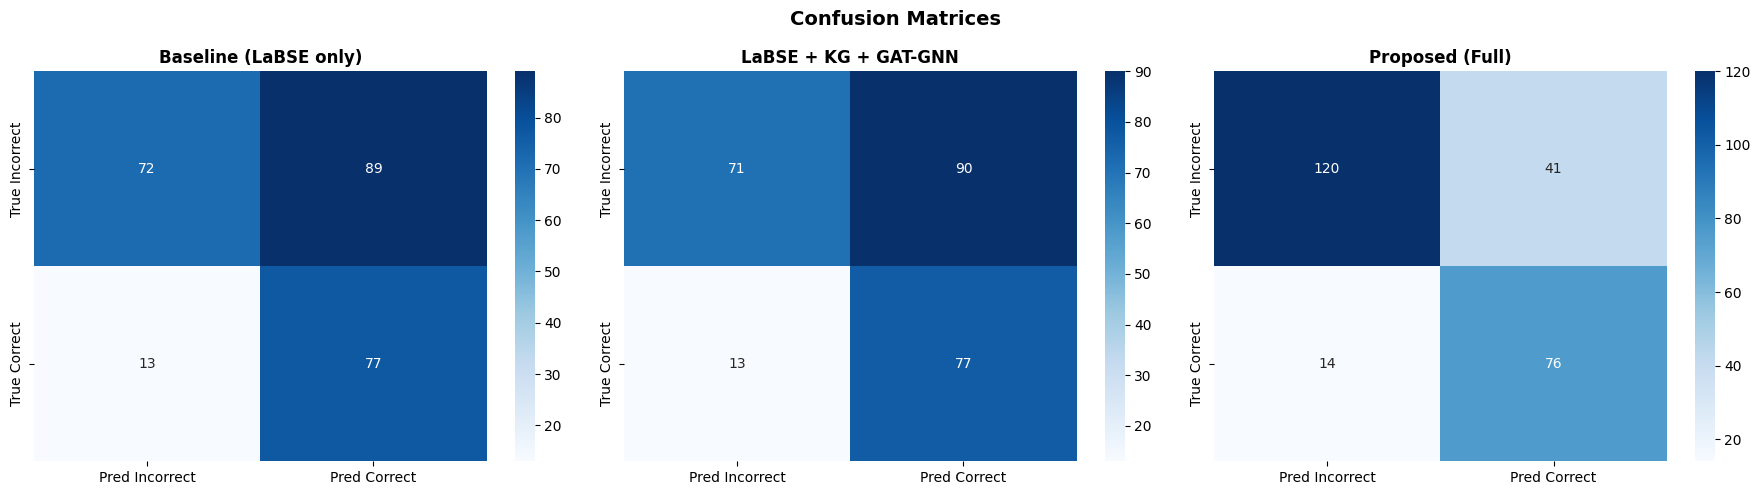

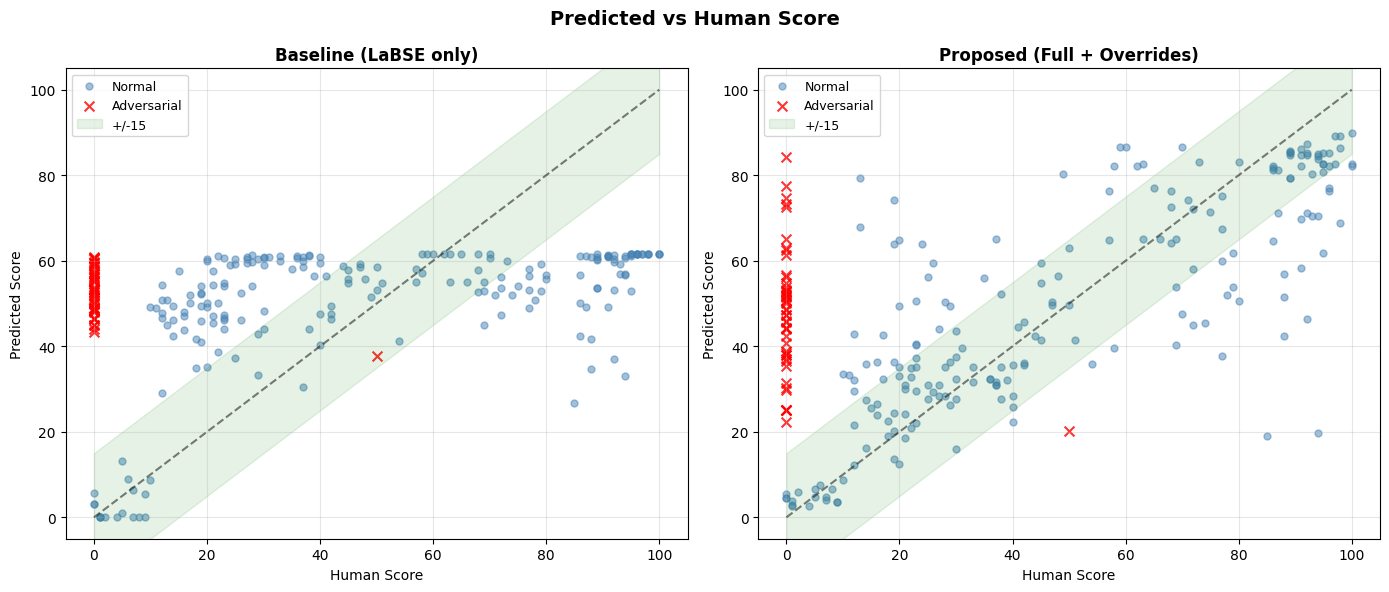

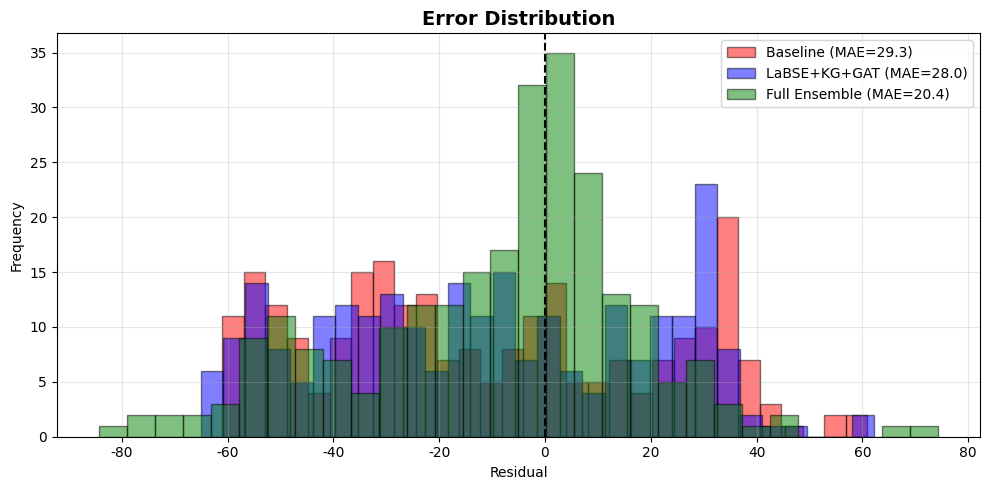

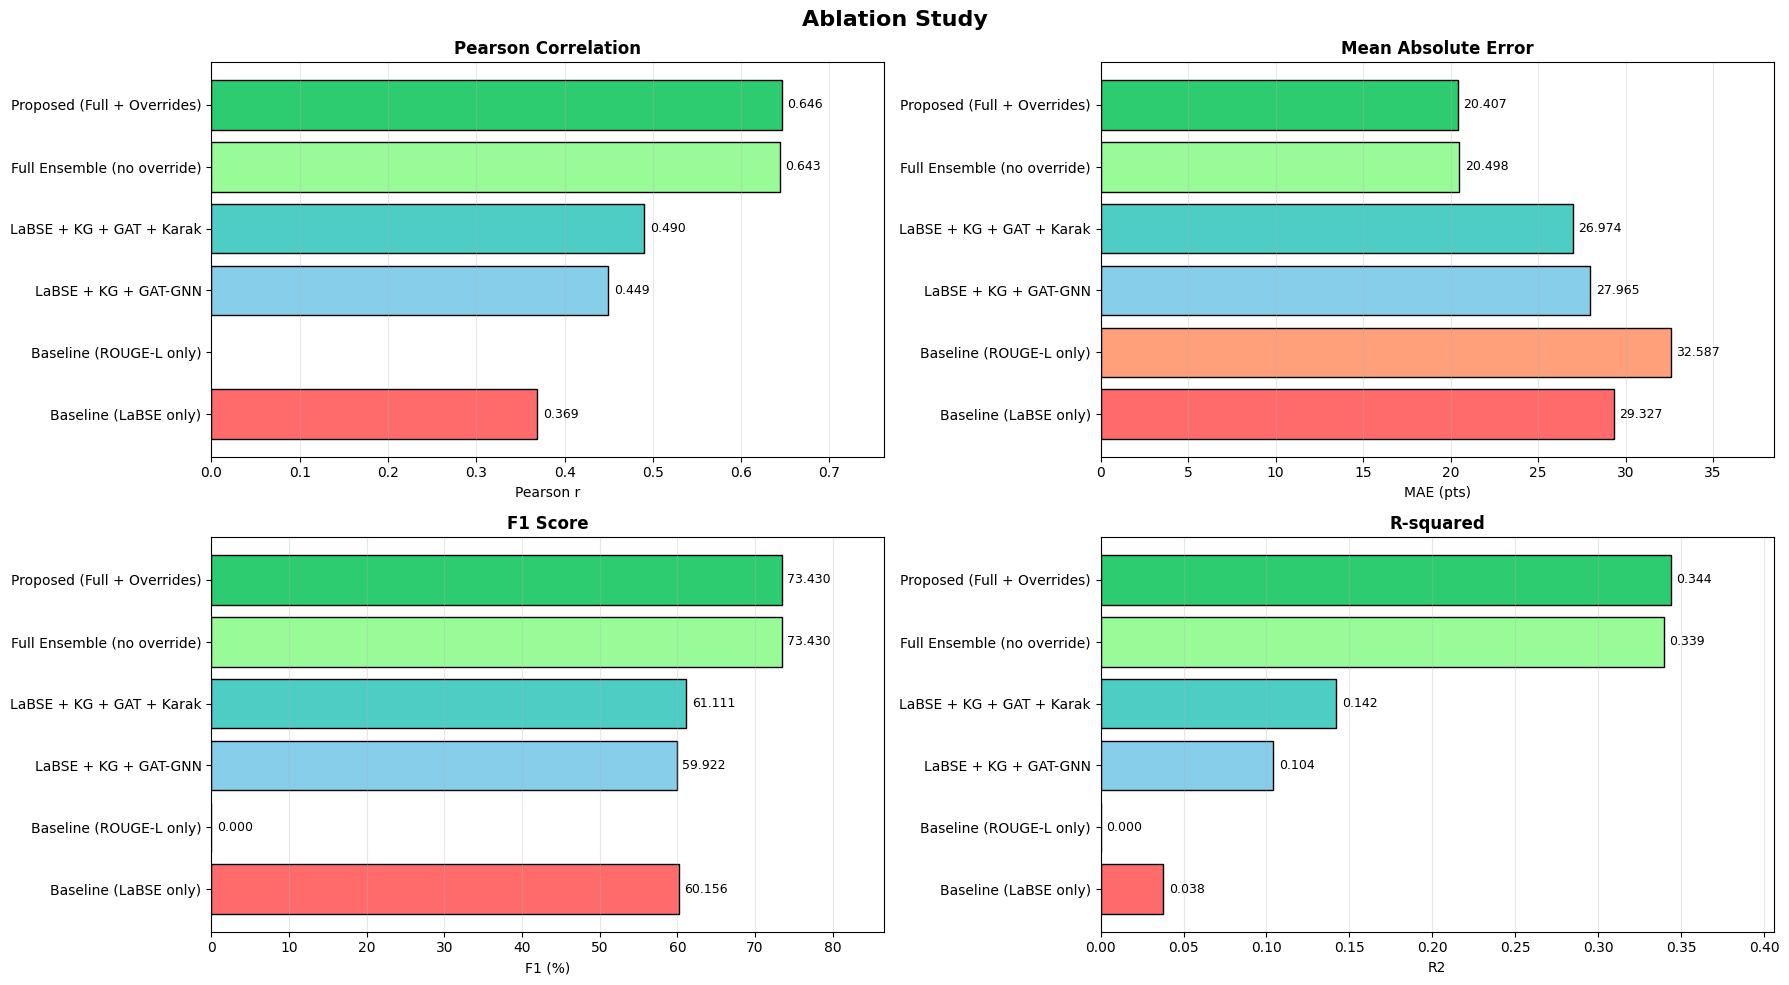

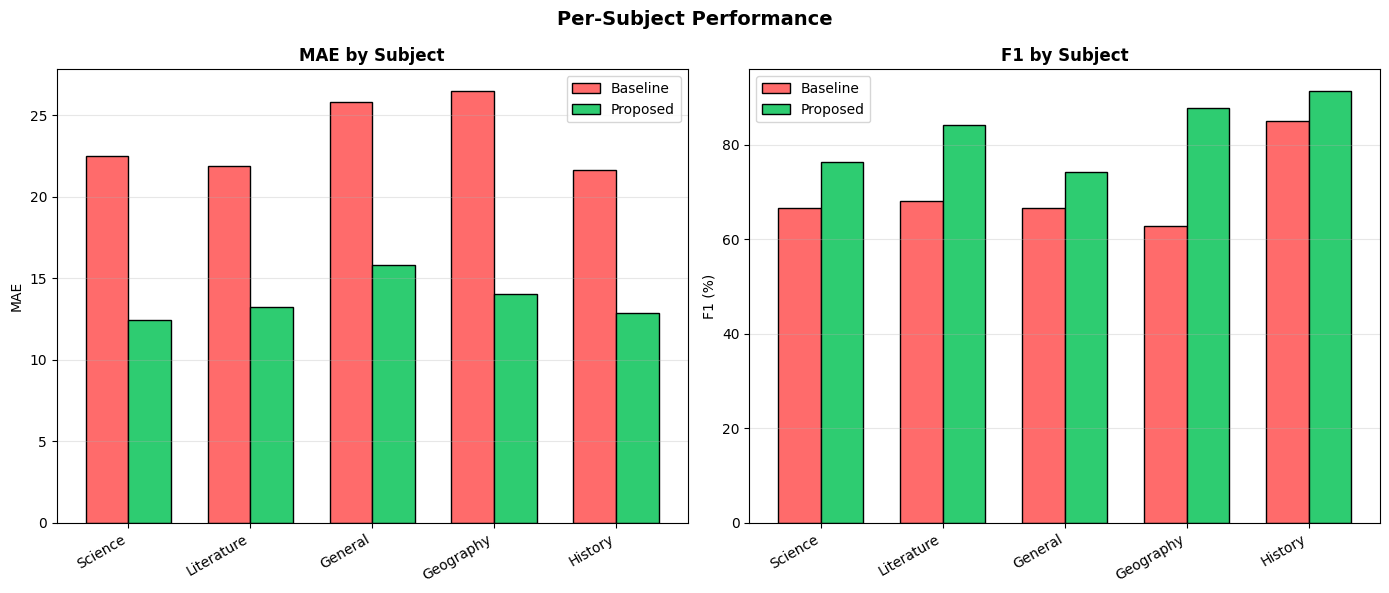

All charts saved.


In [19]:
import matplotlib.patches as mpatches
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.unicode_minus': False})

# ── 1. Confusion matrices ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, [
    ('Baseline (LaBSE only)', y_pred_baseline),
    ('LaBSE + KG + GAT-GNN',  y_pred_kg),
    ('Proposed (Full)',        y_pred_proposed),
]):
    ytc = (y_test >= 50).astype(int)
    ypc = (np.array(yp) >= 50).astype(int)
    cm  = confusion_matrix(ytc, ypc)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Incorrect', 'Pred Correct'],
                yticklabels=['True Incorrect', 'True Correct'])
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Scatter plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, yp) in zip(axes, [
    ('Baseline (LaBSE only)', y_pred_baseline),
    ('Proposed (Full + Overrides)', y_pred_proposed),
]):
    ax.scatter(y_test[:adv_start], yp[:adv_start], alpha=0.5, c='steelblue', s=25, label='Normal')
    ax.scatter(y_test[adv_start:], yp[adv_start:], alpha=0.8, c='red', marker='x', s=50, label='Adversarial')
    ax.plot([0,100],[0,100], 'k--', alpha=0.5)
    ax.fill_between([0,100],[0-15,100-15],[0+15,100+15], alpha=0.1, color='green', label='+/-15')
    ax.set_xlabel('Human Score'); ax.set_ylabel('Predicted Score')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5,105); ax.set_ylim(-5,105)
plt.suptitle('Predicted vs Human Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Error distribution ──
fig, ax = plt.subplots(figsize=(10, 5))
for label, yp, color in [
    ('Baseline', y_pred_baseline, 'red'),
    ('LaBSE+KG+GAT', y_pred_kg, 'blue'),
    ('Full Ensemble', y_pred_proposed, 'green'),
]:
    residuals = np.array(y_test) - np.array(yp)
    ax.hist(residuals, bins=30, alpha=0.5, color=color, edgecolor='black',
            label=f'{label} (MAE={mean_absolute_error(y_test,yp):.1f})')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual'); ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Ablation bar charts ──
model_names = [m['name'] for m in all_metrics]
bar_colors  = ['#FF6B6B','#FFA07A','#87CEEB','#4ECDC4','#98FB98','#2ECC71']
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

def hbar(ax, vals, names, colors, xlabel, title):
    bars = ax.barh(names, vals, color=colors, edgecolor='black')
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, max(vals)*1.18)
    ax.grid(True, alpha=0.3, axis='x')

hbar(axes[0,0], [m['pearson']  for m in all_metrics], model_names, bar_colors, 'Pearson r', 'Pearson Correlation')
hbar(axes[0,1], [m['mae']      for m in all_metrics], model_names, bar_colors, 'MAE (pts)', 'Mean Absolute Error')
hbar(axes[1,0], [m['cls_f1']   for m in all_metrics], model_names, bar_colors, 'F1 (%)',    'F1 Score')
hbar(axes[1,1], [max(v,0) for v in [m['r2'] for m in all_metrics]], model_names, bar_colors, 'R2', 'R-squared')
plt.suptitle('Ablation Study', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Per-subject bar chart ──
if subject_rows:
    subj_labels = [r['subject'] for r in subject_rows]
    x = np.arange(len(subj_labels)); w = 0.35
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.bar(x - w/2, [r['mae_base'] for r in subject_rows], w, label='Baseline', color='#FF6B6B', edgecolor='black')
    ax1.bar(x + w/2, [r['mae_prop'] for r in subject_rows], w, label='Proposed', color='#2ECC71', edgecolor='black')
    ax1.set_xticks(x); ax1.set_xticklabels(subj_labels, rotation=30, ha='right')
    ax1.set_ylabel('MAE'); ax1.set_title('MAE by Subject', fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')
    ax2.bar(x - w/2, [r['f1_base'] for r in subject_rows], w, label='Baseline', color='#FF6B6B', edgecolor='black')
    ax2.bar(x + w/2, [r['f1_prop'] for r in subject_rows], w, label='Proposed', color='#2ECC71', edgecolor='black')
    ax2.set_xticks(x); ax2.set_xticklabels(subj_labels, rotation=30, ha='right')
    ax2.set_ylabel('F1 (%)'); ax2.set_title('F1 by Subject', fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
    plt.suptitle('Per-Subject Performance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('per_subject_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

print('All charts saved.')


## 20. 3-Class Confusion Matrix + Feature Importance

3-Class Accuracy: 0.6175
                   precision    recall  f1-score   support

        incorrect       0.88      0.62      0.73       145
partially_correct       0.22      0.50      0.31        38
          correct       0.73      0.68      0.70        68

         accuracy                           0.62       251
        macro avg       0.61      0.60      0.58       251
     weighted avg       0.74      0.62      0.66       251



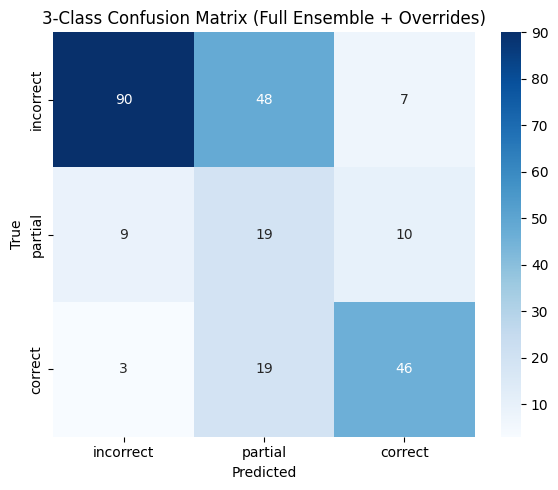

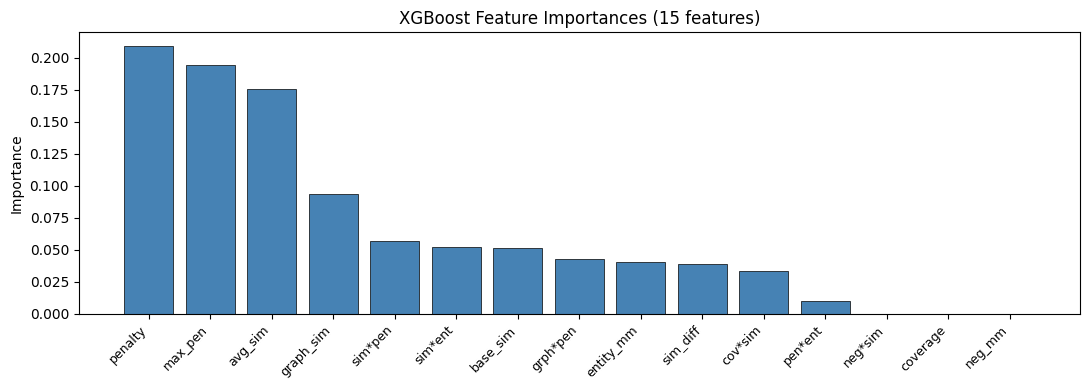

Saved: confusion_3class.png, feature_importance.png


In [20]:
def score_to_3class(s):
    return 0 if s < 40 else (1 if s < 70 else 2)

y_true_3 = [score_to_3class(s) for s in y_test]
y_pred_3 = [score_to_3class(s) for s in y_pred_proposed]
print('3-Class Accuracy:', f'{accuracy_score(y_true_3, y_pred_3):.4f}')
print(classification_report(y_true_3, y_pred_3,
      target_names=['incorrect','partially_correct','correct']))

cm3 = confusion_matrix(y_true_3, y_pred_3)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['incorrect','partial','correct'],
            yticklabels=['incorrect','partial','correct'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('3-Class Confusion Matrix (Full Ensemble + Overrides)')
plt.tight_layout()
plt.savefig('confusion_3class.png', dpi=150)
plt.show()

feat_names = ['base_sim','graph_sim','penalty','entity_mm','coverage','neg_mm',
              'sim*pen','sim*ent','grph*pen','pen*ent','sim_diff','avg_sim',
              'max_pen','cov*sim','neg*sim']
imp = scorer.xgb_model.feature_importances_
si  = np.argsort(imp)[::-1]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(imp)), imp[si], color='steelblue', edgecolor='black', lw=0.5)
ax.set_xticks(range(len(imp)))
ax.set_xticklabels([feat_names[i] for i in si], rotation=45, ha='right', fontsize=9)
ax.set_title('XGBoost Feature Importances (15 features)')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: confusion_3class.png, feature_importance.png')


## 21. Knowledge Graph Visualization

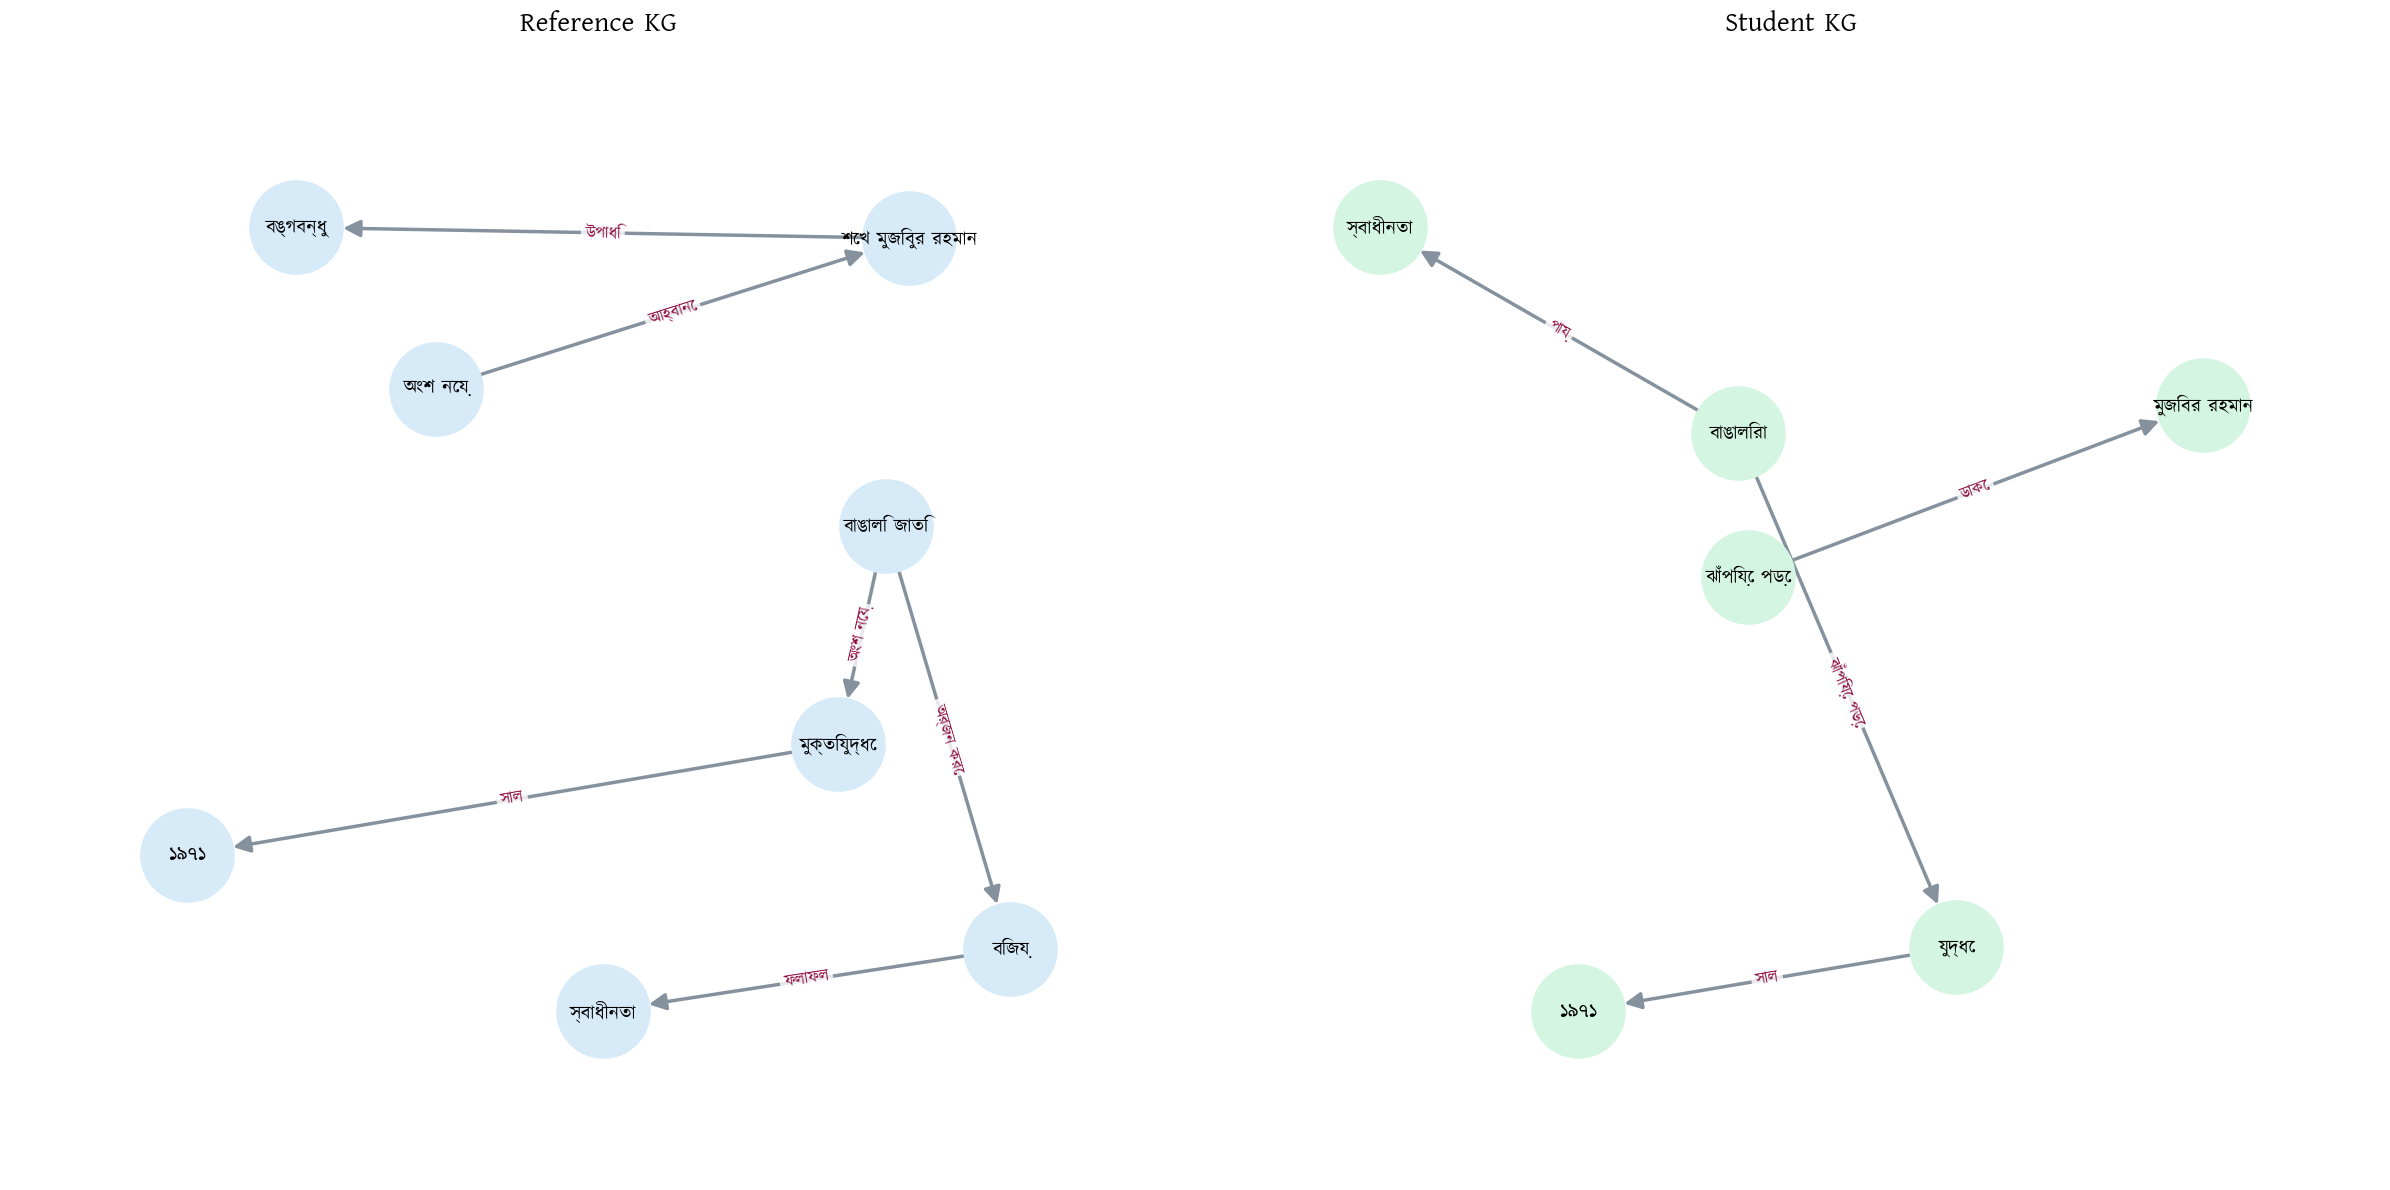

[OK] Knowledge graph saved.


In [21]:
import urllib.request

font_url  = 'https://www.omicronlab.com/download/fonts/kalpurush.ttf'
font_path = 'kalpurush.ttf'
if not os.path.exists(font_path):
    print('Downloading Bengali font...')
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
bengali_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = bengali_font.get_name()

ref_triples_demo = [
    ('বাঙালি জাতি', 'অংশ নেয়', 'মুক্তিযুদ্ধে'),
    ('মুক্তিযুদ্ধে', 'সাল', '১৯৭১'),
    ('অংশ নেয়', 'আহ্বানে', 'শেখ মুজিবুর রহমান'),
    ('শেখ মুজিবুর রহমান', 'উপাধি', 'বঙ্গবন্ধু'),
    ('বাঙালি জাতি', 'অর্জন করে', 'বিজয়'),
    ('বিজয়', 'ফলাফল', 'স্বাধীনতা'),
]
stu_triples_demo = [
    ('বাঙালিরা', 'ঝাঁপিয়ে পড়ে', 'যুদ্ধে'),
    ('যুদ্ধে', 'সাল', '১৯৭১'),
    ('ঝাঁপিয়ে পড়ে', 'ডাকে', 'মুজিবর রহমান'),
    ('বাঙালিরা', 'পায়', 'স্বাধীনতা'),
]

G_ref_demo = nx.DiGraph()
for s, r, o in ref_triples_demo:
    G_ref_demo.add_edge(s, o, label=r)

G_stu_demo = nx.DiGraph()
for s, r, o in stu_triples_demo:
    G_stu_demo.add_edge(s, o, label=r)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
fig.patch.set_facecolor('white')

for ax, G, title, color in [
    (axes[0], G_ref_demo, 'Reference KG', '#D6EAF8'),
    (axes[1], G_stu_demo, 'Student KG',   '#D5F5E3'),
]:
    pos = nx.spring_layout(G, k=5.0, iterations=200, seed=42)
    nx.draw(G, pos, ax=ax, node_color=color, node_size=4500,
            edge_color='#85929E', width=2.5, arrows=True, arrowsize=25)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=14,
                             font_family=bengali_font.get_name(), font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'label'), ax=ax,
        font_family=bengali_font.get_name(), font_size=12, font_color='#900C3F',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=3))
    ax.set_title(title, fontsize=20, fontweight='bold', pad=20)
    ax.margins(0.15)

plt.tight_layout()
plt.savefig('knowledge_graph.png', dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Knowledge graph saved.')


## 22. Save Models

In [22]:
torch.save(gnn.state_dict(), 'nlp_dominator_gnn.pth')
scorer.save_model('nlp_dominator_scorer.pkl')
print('[OK] Models saved: nlp_dominator_gnn.pth, nlp_dominator_scorer.pkl')


Saved to nlp_dominator_scorer.pkl
[OK] Models saved: nlp_dominator_gnn.pth, nlp_dominator_scorer.pkl


## 23. NEW — Gradio Interactive Demo

In [23]:
import gradio as gr

# ── Inference helper ──
def predict_single(question: str, reference_answer: str, student_answer: str):
    """Full pipeline inference for a single (q, ref, stu) triple."""
    if not question.strip() or not reference_answer.strip() or not student_answer.strip():
        return "Please fill in all three fields.", "", 0.0

    # 1. Coreference resolution
    stu_resolved = coref_resolver.resolve(student_answer, question, reference_answer)

    # 2. LaBSE similarity
    base_sim = embedder.cosine_similarity(reference_answer, stu_resolved)

    # 3. Dependency parsing
    ref_parsed = dep_parser.parse(text_processor.normalize(reference_answer))
    stu_parsed = dep_parser.parse(text_processor.normalize(stu_resolved))

    # 4. Triple extraction + KG
    ref_triples = triple_extractor.extract_triples(raw_text=reference_answer)
    stu_triples = triple_extractor.extract_triples(raw_text=stu_resolved)
    ref_kg = kg_constructor.build_graph(ref_triples)
    stu_kg = kg_constructor.build_graph(stu_triples)

    # 5. Node embeddings + GAT-GNN similarity
    ref_emb = embedder.generate_node_embeddings(ref_kg)
    stu_emb = embedder.generate_node_embeddings(stu_kg)
    pyg_ref = nx_to_pyg_data(ref_kg, ref_emb)
    pyg_stu = nx_to_pyg_data(stu_kg, stu_emb)
    gnn.eval()
    with torch.no_grad():
        graph_sim = max(0.0, gnn(pyg_ref, pyg_stu).item())

    # 6. Karak validation
    penalty, explanations = validator.validate(ref_parsed, stu_parsed,
                                               ref_raw=reference_answer, stu_raw=stu_resolved)

    # 7. Entity mismatch
    entity_mm = compute_entity_mismatch(ref_parsed, stu_parsed, reference_answer, stu_resolved,
                                        embedder_obj=embedder, ner_pipeline_obj=ner_pipe)

    # 8. Coverage + negation + ROUGE-L
    coverage   = sentence_coverage_score(reference_answer, stu_resolved, embedder)
    neg_mm     = negation_mismatch(reference_answer, stu_resolved)
    rouge_l    = compute_rouge_l(reference_answer, stu_resolved)

    # 9. Ensemble prediction
    X = np.array([[base_sim, graph_sim, penalty, entity_mm, coverage, neg_mm]])
    raw_score = scorer.predict_score(base_sim, graph_sim, penalty, entity_mm, coverage, neg_mm)

    # 10. Hard overrides
    applied_overrides = []
    final_score = raw_score
    if neg_mm == 1.0 and final_score > 30.0:
        final_score = 30.0
        applied_overrides.append('Negation mismatch — score capped at 30')

    # Check for wrong numeric
    ref_roles_num = set()
    stu_roles_num = set()
    for sent in ref_parsed:
        for word in sent:
            if is_bengali_numeral(word['text']) or word['deprel'] == 'nummod':
                ref_roles_num.add(normalize_digits(word['text']))
    for sent in stu_parsed:
        for word in sent:
            if is_bengali_numeral(word['text']) or word['deprel'] == 'nummod':
                stu_roles_num.add(normalize_digits(word['text']))
    wrong_num = stu_roles_num - ref_roles_num
    if wrong_num and ref_roles_num and final_score > 25.0:
        final_score = 25.0
        applied_overrides.append(f'Wrong numeric value {wrong_num} — score capped at 25')

    # 11. Determine label
    if final_score >= 70:
        label = '✅ Correct'
        color_label = 'correct'
    elif final_score >= 40:
        label = '⚠️ Partially Correct'
        color_label = 'partial'
    else:
        label = '❌ Incorrect'
        color_label = 'incorrect'

    # 12. Question type
    q_type = detect_question_type(question)

    # 13. Build explanation
    explanation = scorer.generate_explanation(
        final_score, base_sim, graph_sim, penalty, explanations,
        entity_mismatch=entity_mm, coverage=coverage,
        neg_mismatch_val=neg_mm, question_type=q_type,
        rouge_l=rouge_l, applied_overrides=applied_overrides
    )

    return label, explanation, round(final_score, 2)


# ── Gradio UI ──
with gr.Blocks(
    title='Bengali Answer Evaluation System',
    theme=gr.themes.Soft(
        primary_hue='blue',
        secondary_hue='green',
        neutral_hue='gray',
    ),
    css="""
        .score-box { font-size: 2.5em; font-weight: bold; text-align: center; padding: 20px; border-radius: 10px; }
        .correct-box { background: #d4edda; color: #155724; }
        .partial-box { background: #fff3cd; color: #856404; }
        .incorrect-box { background: #f8d7da; color: #721c24; }
        #title { text-align: center; margin-bottom: 10px; }
        .footer { text-align: center; color: #888; font-size: 0.85em; margin-top: 15px; }
    """
) as demo:

    gr.HTML("""
        <div id='title'>
            <h1>🔤 Bengali Answer Evaluation System</h1>
            <p style='color:#555;'>Automatic short-answer grading using Knowledge Graphs + GAT-GNN + XGBoost</p>
            <p style='color:#777; font-size:0.9em;'>NLP Dominator | IIIT Hyderabad</p>
        </div>
    """)

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown('### 📝 Input')
            question_input = gr.Textbox(
                label='Question (প্রশ্ন)',
                placeholder='যেমন: বাংলাদেশ কবে স্বাধীন হয়েছিল?',
                lines=2
            )
            reference_input = gr.Textbox(
                label='Reference Answer (সঠিক উত্তর)',
                placeholder='যেমন: বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।',
                lines=3
            )
            student_input = gr.Textbox(
                label='Student Answer (ছাত্রের উত্তর)',
                placeholder='যেমন: বাংলাদেশ ১৯৭২ সালে স্বাধীন হয়েছিল।',
                lines=3
            )

            with gr.Row():
                submit_btn = gr.Button('🚀 Evaluate Answer', variant='primary', scale=3)
                clear_btn  = gr.Button('🗑️ Clear', variant='secondary', scale=1)

        with gr.Column(scale=1):
            gr.Markdown('### 📊 Result')
            score_output = gr.Number(label='Score (0–100)', precision=2)
            label_output = gr.Textbox(label='Verdict', interactive=False)

    gr.Markdown('### 🔍 Detailed Explanation')
    explanation_output = gr.Textbox(
        label='Component Breakdown',
        lines=18,
        interactive=False,
        show_copy_button=True
    )

    gr.Markdown('### 📚 Example Test Cases')
    examples = gr.Examples(
        examples=[
            ['বাংলাদেশ কবে স্বাধীন হয়েছিল?',
             'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।',
             'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।'],
            ['বাংলাদেশ কবে স্বাধীন হয়েছিল?',
             'বাংলাদেশ ১৯৭১ সালে স্বাধীন হয়েছিল।',
             'বাংলাদেশ ১৯৭২ সালে স্বাধীন হয়েছিল।'],
            ['সূর্য কোথায় ওঠে?',
             'সূর্য পূর্বদিকে ওঠে।',
             'সূর্য পূর্বদিকে ওঠে না।'],
            ['কে রাবণকে বধ করেছিলেন?',
             'রাম রাবণকে বধ করেছিলেন।',
             'রাবণ রামকে বধ করেছিলেন।'],
            ['পৃথিবী কীসের চারদিকে ঘোরে?',
             'পৃথিবী সূর্যের চারদিকে ঘোরে।',
             'পৃথিবী সূর্যের চারদিকে ঘোরে।'],
            ['মানুষের শরীরে কয়টি হাড় থাকে?',
             'মানুষের শরীরে ২০৬টি হাড় থাকে।',
             'মানুষের শরীরে ২০৫টি হাড় থাকে।'],
            ['মুক্তিযুদ্ধ সম্পর্কে বলো।',
             'বাংলাদেশের মুক্তিযুদ্ধ ১৯৭১ সালে হয়েছিল। এটি নয় মাস স্থায়ী হয়েছিল।',
             'মুক্তিযুদ্ধ ১৯৭১ সালে হয়েছিল।'],
            ['গীতাঞ্জলি কে লিখেছিলেন?',
             'রবীন্দ্রনাথ ঠাকুর গীতাঞ্জলি লিখেছিলেন।',
             'রবীন্দ্রনাথ ঠাকুর গীতাঞ্জলি।'],
        ],
        inputs=[question_input, reference_input, student_input],
    )

    gr.HTML("""
        <div class='footer'>
            <p>🏛️ Knowledge Graphs Based Bengali Answer Evaluation | NLP Dominator | IIIT Hyderabad 2025</p>
            <p>Pipeline: LaBSE + BNLP POS + KG + Siamese GAT-GNN + Karak Validator + XGBoost+MLP Ensemble</p>
        </div>
    """)

    # Wire up buttons
    submit_btn.click(
        fn=predict_single,
        inputs=[question_input, reference_input, student_input],
        outputs=[label_output, explanation_output, score_output]
    )
    clear_btn.click(
        fn=lambda: ('', '', '', '', 0.0),
        inputs=[],
        outputs=[question_input, reference_input, student_input, label_output, score_output]
    )

print('[OK] Gradio interface defined. Launching...')
demo.launch(share=True, debug=False)


[OK] Gradio interface defined. Launching...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://38df218fcce8501a35.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 24. Load Pre-trained Models for Inference

In [24]:
def load_pretrained_models():
    gnn_path    = 'nlp_dominator_gnn.pth'
    scorer_path = 'nlp_dominator_scorer.pkl'
    if not os.path.exists(gnn_path) or not os.path.exists(scorer_path):
        print('[WARN] Model files not found. Run training pipeline first.')
        return None, None
    loaded_gnn = SiameseGNN()
    loaded_gnn.load_state_dict(torch.load(gnn_path, map_location='cpu', weights_only=True))
    loaded_gnn.eval()
    loaded_scorer = AnswerScorer()
    loaded_scorer.load_model(scorer_path)
    print('[OK] GAT-GNN + XGBoost+MLP loaded for inference.')
    return loaded_gnn, loaded_scorer

infer_gnn, infer_scorer = load_pretrained_models()
print('\n[OK] Notebook complete!')


Loaded from nlp_dominator_scorer.pkl
[OK] GAT-GNN + XGBoost+MLP loaded for inference.

[OK] Notebook complete!
